In [15]:
%load_ext autoreload
%autoreload 2
import pandas as pd 
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import fonctions 
import embeddingsFunctions as ef
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
import umap
import seaborn as sns
from sklearn.cluster import KMeans
from collections import Counter
from matplotlib.lines import Line2D
import pickle
from BaryCentreClassifier import BarycenterClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Initialisation de la liste avec les noms des fichiers (sans l'extension .csv)
# unique cellule a changer , on donne les fichiers a qui on veut appliquer le pipeline
# les fichiers doivent être au format csv
# dans la liste on met les noms des fichier sans les .csv
list_files = [
    "graph_2022-01-01_to_2022-01-14", "graph_2022-01-01_to_2022-01-21",
    "graph_2022-01-08_to_2022-01-21", "graph_2022-01-08_to_2022-01-28",
    "graph_2022-01-15_to_2022-01-28", "graph_2022-01-15_to_2022-02-04",
    "graph_2022-01-22_to_2022-02-04", "graph_2022-01-22_to_2022-02-11",
    "graph_2022-01-29_to_2022-02-11", "graph_2022-01-29_to_2022-02-18",
    "graph_2022-02-05_to_2022-02-18", "graph_2022-02-05_to_2022-02-25",
    "graph_2022-02-12_to_2022-02-25", "graph_2022-02-12_to_2022-03-04",
    "graph_2022-02-19_to_2022-03-04", "graph_2022-02-19_to_2022-03-11",
    "graph_2022-02-26_to_2022-03-11", "graph_2022-02-26_to_2022-03-18",
    "graph_2022-03-05_to_2022-03-25", "graph_2022-03-12_to_2022-04-01",
    "graph_2022-03-19_to_2022-04-08", "graph_2022-03-26_to_2022-04-15",
    "graph_2022-04-02_to_2022-04-22", "graph_2022-04-09_to_2022-04-29",
    "graph_2022-04-16_to_2022-05-06", "graph_2022-04-23_to_2022-05-13",
    "graph_2022-04-30_to_2022-05-20", "graph_2022-05-07_to_2022-05-27",
    "graph_2022-05-14_to_2022-06-03", "graph_2022-05-21_to_2022-06-10",
    "graph_2022-05-28_to_2022-06-17", "graph_2022-06-04_to_2022-06-24",
    "graph_2022-06-11_to_2022-07-01", "graph_2022-06-18_to_2022-07-08",
    "graph_2022-06-25_to_2022-07-15", "graph_2022-07-02_to_2022-07-22",
    "graph_2022-07-09_to_2022-07-29", "graph_2022-07-16_to_2022-08-05",
    "graph_2022-07-23_to_2022-08-12", "graph_2022-07-30_to_2022-08-19",
    "graph_2022-08-06_to_2022-08-26", "graph_2022-08-13_to_2022-09-02",
    "graph_2022-08-20_to_2022-09-09", "graph_2022-08-27_to_2022-09-16",
    "graph_2022-09-03_to_2022-09-23", "graph_2022-09-10_to_2022-09-30",
    "graph_2022-09-17_to_2022-10-07", "graph_2022-09-24_to_2022-10-14",
    "graph_2022-10-01_to_2022-10-21", "graph_2022-10-08_to_2022-10-28",
    "graph_2022-10-15_to_2022-11-04", "graph_2022-10-22_to_2022-11-11",
    "graph_2022-10-29_to_2022-11-18", "graph_2022-11-05_to_2022-11-25",
    "graph_2022-11-12_to_2022-12-02", "graph_2022-11-19_to_2022-12-09",
    "graph_2022-11-26_to_2022-12-16", "graph_2022-12-03_to_2022-12-23",
    "graph_2022-12-10_to_2022-12-30"
]

In [3]:
# Cellule qui lit les fichier puis créer des graphes et les sauvgardes sous plusieurs formats
# Initialisation du dictionnaire vide avant la boucle
dictionnaire_graphes = {}

# Création et sauvegarde des graphes en parcourant la liste
for fichier in list_files:
    # Lecture du fichier CSV (on ajoute l'extension .csv ici)
    df = pd.read_csv(f"{fichier}.csv")
    
    # Création du graphe
    G = nx.from_pandas_edgelist(
        df,
        source='user_id',
        target='original_author',
        edge_attr='nb_retweeted'
    )
    
    # Ajout du graphe dans le dictionnaire avec le nom de base comme clé
    dictionnaire_graphes[fichier] = G
    
    # Sauvegarde au format pickle
    # pour pouvoir sauvegrader le graphe et le relire d'un fichier sans executer toute la cellule et le recuperer du dict 
    with open(f"graph_{fichier}.gpickle", "wb") as f:
        pickle.dump(G, f)
    
    # Sauvegarde au format GEXF compatible avec GEPHI
    nx.write_gexf(G, f"graph_{fichier}.gexf")
    
    # Message de confirmation
    print(f"graph_{fichier} sauvegardé et ajouté au dictionnaire")

# Pour vérifier que le dictionnaire contient bien tes graphes :
print("\nClés du dictionnaire :", dictionnaire_graphes.keys())

graph_graph_2022-01-01_to_2022-01-14 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-01_to_2022-01-21 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-08_to_2022-01-21 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-08_to_2022-01-28 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-15_to_2022-01-28 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-15_to_2022-02-04 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-22_to_2022-02-04 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-22_to_2022-02-11 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-29_to_2022-02-11 sauvegardé et ajouté au dictionnaire
graph_graph_2022-01-29_to_2022-02-18 sauvegardé et ajouté au dictionnaire
graph_graph_2022-02-05_to_2022-02-18 sauvegardé et ajouté au dictionnaire
graph_graph_2022-02-05_to_2022-02-25 sauvegardé et ajouté au dictionnaire
graph_graph_2022-02-12_to_2022-02-25 sauvegardé et ajouté au dictionnaire
graph_graph_2022-02-12_to_2022-03-04 s

In [ ]:
#Cellule pas importante: pour visualiser un graphe si cela est voulu 

# Pour visualiser un graphe spécifique
nom_graphe = 'part_01'  # À remplacer par une clé existante
G = dictionnaire_graphes[nom_graphe]

# Visualisation basique
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1, iterations=50)
nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', 
        font_size=8, font_weight='bold')
plt.title(f"Graphe des retweets - {nom_graphe}")
plt.show()

# Ou avec les poids des arêtes (nb_retweeted)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1, iterations=50)
edges = G.edges()
weights = [G[u][v]['nb_retweeted'] for u, v in edges]

nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue',
        font_size=8, font_weight='bold', width=[w/10 for w in weights])
plt.title(f"Graphe des retweets (épaisseur = nb_retweeted) - {nom_graphe}")
plt.show()

In [4]:
# Cellule qui lit les fichier des graph puis applique Node2Vec pour tous les graphes de la liste et sauvgarde les resultats
# on execute cette cellule une seule fois car elle prend bcp de temps
# si on a pas deja les fichiers embeddings32_{fichier}.csv et si on les a pas la peine de l'executer

# Parcours de tous les fichiers dans list_files
for fichier in list_files:
    print(f"\nTraitement de Node2Vec : {fichier}")
    
    # Rechargement du graphe déjà créé
    with open(f"graph_{fichier}.gpickle", "rb") as f:
        G = pickle.load(f)
    
    print(f"Nombre de nœuds : {G.number_of_nodes()}")
    print(f"Nombre d'arêtes : {G.number_of_edges()}")
    
    # Application de node2vec pour les embeddings 32 dimensions
    ef.embedding32dimensions(G)
    
    # Renommage du fichier de sortie
    if os.path.exists('embeddings32dimensions.csv'):
        os.rename('embeddings32dimensions.csv', f'embeddings32_{fichier}.csv')
        print(f"Embeddings sauvegardés dans embeddings32_{fichier}.csv")
    
    print(f"Terminé pour {fichier}\n")
    
    # Libération de la mémoire
    del G


Traitement de Node2Vec : graph_2022-01-01_to_2022-01-14
Nombre de nœuds : 37873
Nombre d'arêtes : 46922


Computing transition probabilities:   0%|          | 0/37873 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [01:44<00:00, 10.43s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-01_to_2022-01-14.csv
Terminé pour graph_2022-01-01_to_2022-01-14


Traitement de Node2Vec : graph_2022-01-01_to_2022-01-21
Nombre de nœuds : 59036
Nombre d'arêtes : 77796


Computing transition probabilities:   0%|          | 0/59036 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:07<00:00, 18.72s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-01_to_2022-01-21.csv
Terminé pour graph_2022-01-01_to_2022-01-21


Traitement de Node2Vec : graph_2022-01-08_to_2022-01-21
Nombre de nœuds : 39824
Nombre d'arêtes : 48388


Computing transition probabilities:   0%|          | 0/39824 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [01:53<00:00, 11.30s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-08_to_2022-01-21.csv
Terminé pour graph_2022-01-08_to_2022-01-21


Traitement de Node2Vec : graph_2022-01-08_to_2022-01-28
Nombre de nœuds : 60936
Nombre d'arêtes : 78433


Computing transition probabilities:   0%|          | 0/60936 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:29<00:00, 20.99s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-08_to_2022-01-28.csv
Terminé pour graph_2022-01-08_to_2022-01-28


Traitement de Node2Vec : graph_2022-01-15_to_2022-01-28
Nombre de nœuds : 41046
Nombre d'arêtes : 48824


Computing transition probabilities:   0%|          | 0/41046 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [02:25<00:00, 14.50s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-15_to_2022-01-28.csv
Terminé pour graph_2022-01-15_to_2022-01-28


Traitement de Node2Vec : graph_2022-01-15_to_2022-02-04
Nombre de nœuds : 60355
Nombre d'arêtes : 76270


Computing transition probabilities:   0%|          | 0/60355 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [02:29<00:00, 14.98s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-15_to_2022-02-04.csv
Terminé pour graph_2022-01-15_to_2022-02-04


Traitement de Node2Vec : graph_2022-01-22_to_2022-02-04
Nombre de nœuds : 38234
Nombre d'arêtes : 44137


Computing transition probabilities:   0%|          | 0/38234 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [01:12<00:00,  7.25s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-22_to_2022-02-04.csv
Terminé pour graph_2022-01-22_to_2022-02-04


Traitement de Node2Vec : graph_2022-01-22_to_2022-02-11
Nombre de nœuds : 60535
Nombre d'arêtes : 76024


Computing transition probabilities:   0%|          | 0/60535 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [02:51<00:00, 17.19s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-22_to_2022-02-11.csv
Terminé pour graph_2022-01-22_to_2022-02-11


Traitement de Node2Vec : graph_2022-01-29_to_2022-02-11
Nombre de nœuds : 39518
Nombre d'arêtes : 45771


Computing transition probabilities:   0%|          | 0/39518 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [01:42<00:00, 10.28s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-29_to_2022-02-11.csv
Terminé pour graph_2022-01-29_to_2022-02-11


Traitement de Node2Vec : graph_2022-01-29_to_2022-02-18
Nombre de nœuds : 58645
Nombre d'arêtes : 73133


Computing transition probabilities:   0%|          | 0/58645 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:03<00:00, 18.37s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-01-29_to_2022-02-18.csv
Terminé pour graph_2022-01-29_to_2022-02-18


Traitement de Node2Vec : graph_2022-02-05_to_2022-02-18
Nombre de nœuds : 38652
Nombre d'arêtes : 44682


Computing transition probabilities:   0%|          | 0/38652 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [02:07<00:00, 12.71s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-05_to_2022-02-18.csv
Terminé pour graph_2022-02-05_to_2022-02-18


Traitement de Node2Vec : graph_2022-02-05_to_2022-02-25
Nombre de nœuds : 56892
Nombre d'arêtes : 69595


Computing transition probabilities:   0%|          | 0/56892 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:23<00:00, 20.37s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-05_to_2022-02-25.csv
Terminé pour graph_2022-02-05_to_2022-02-25


Traitement de Node2Vec : graph_2022-02-12_to_2022-02-25
Nombre de nœuds : 34820
Nombre d'arêtes : 38788


Computing transition probabilities:   0%|          | 0/34820 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:54<00:00,  5.44s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-12_to_2022-02-25.csv
Terminé pour graph_2022-02-12_to_2022-02-25


Traitement de Node2Vec : graph_2022-02-12_to_2022-03-04
Nombre de nœuds : 56094
Nombre d'arêtes : 69275


Computing transition probabilities:   0%|          | 0/56094 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [02:08<00:00, 12.81s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-12_to_2022-03-04.csv
Terminé pour graph_2022-02-12_to_2022-03-04


Traitement de Node2Vec : graph_2022-02-19_to_2022-03-04
Nombre de nœuds : 37250
Nombre d'arêtes : 42746


Computing transition probabilities:   0%|          | 0/37250 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [01:01<00:00,  6.15s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-19_to_2022-03-04.csv
Terminé pour graph_2022-02-19_to_2022-03-04


Traitement de Node2Vec : graph_2022-02-19_to_2022-03-11
Nombre de nœuds : 61817
Nombre d'arêtes : 79393


Computing transition probabilities:   0%|          | 0/61817 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [02:19<00:00, 13.98s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-19_to_2022-03-11.csv
Terminé pour graph_2022-02-19_to_2022-03-11


Traitement de Node2Vec : graph_2022-02-26_to_2022-03-11
Nombre de nœuds : 43168
Nombre d'arêtes : 53610


Computing transition probabilities:   0%|          | 0/43168 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [01:17<00:00,  7.72s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-26_to_2022-03-11.csv
Terminé pour graph_2022-02-26_to_2022-03-11


Traitement de Node2Vec : graph_2022-02-26_to_2022-03-18
Nombre de nœuds : 61666
Nombre d'arêtes : 81782


Computing transition probabilities:   0%|          | 0/61666 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [02:19<00:00, 13.94s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-02-26_to_2022-03-18.csv
Terminé pour graph_2022-02-26_to_2022-03-18


Traitement de Node2Vec : graph_2022-03-05_to_2022-03-25
Nombre de nœuds : 64208
Nombre d'arêtes : 84757


Computing transition probabilities:   0%|          | 0/64208 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:18<00:00, 19.86s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-03-05_to_2022-03-25.csv
Terminé pour graph_2022-03-05_to_2022-03-25


Traitement de Node2Vec : graph_2022-03-12_to_2022-04-01
Nombre de nœuds : 60998
Nombre d'arêtes : 80719


Computing transition probabilities:   0%|          | 0/60998 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:50<00:00, 23.08s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-03-12_to_2022-04-01.csv
Terminé pour graph_2022-03-12_to_2022-04-01


Traitement de Node2Vec : graph_2022-03-19_to_2022-04-08
Nombre de nœuds : 69549
Nombre d'arêtes : 94269


Computing transition probabilities:   0%|          | 0/69549 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [05:39<00:00, 33.94s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-03-19_to_2022-04-08.csv
Terminé pour graph_2022-03-19_to_2022-04-08


Traitement de Node2Vec : graph_2022-03-26_to_2022-04-15
Nombre de nœuds : 68945
Nombre d'arêtes : 91991


Computing transition probabilities:   0%|          | 0/68945 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:20<00:00, 20.01s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-03-26_to_2022-04-15.csv
Terminé pour graph_2022-03-26_to_2022-04-15


Traitement de Node2Vec : graph_2022-04-02_to_2022-04-22
Nombre de nœuds : 74040
Nombre d'arêtes : 98284


Computing transition probabilities:   0%|          | 0/74040 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [04:35<00:00, 27.55s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-04-02_to_2022-04-22.csv
Terminé pour graph_2022-04-02_to_2022-04-22


Traitement de Node2Vec : graph_2022-04-09_to_2022-04-29
Nombre de nœuds : 78029
Nombre d'arêtes : 105021


Computing transition probabilities:   0%|          | 0/78029 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [05:50<00:00, 35.08s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-04-09_to_2022-04-29.csv
Terminé pour graph_2022-04-09_to_2022-04-29


Traitement de Node2Vec : graph_2022-04-16_to_2022-05-06
Nombre de nœuds : 77698
Nombre d'arêtes : 104153


Computing transition probabilities:   0%|          | 0/77698 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [05:20<00:00, 32.09s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-04-16_to_2022-05-06.csv
Terminé pour graph_2022-04-16_to_2022-05-06


Traitement de Node2Vec : graph_2022-04-23_to_2022-05-13
Nombre de nœuds : 74742
Nombre d'arêtes : 98782


Computing transition probabilities:   0%|          | 0/74742 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [06:24<00:00, 38.48s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-04-23_to_2022-05-13.csv
Terminé pour graph_2022-04-23_to_2022-05-13


Traitement de Node2Vec : graph_2022-04-30_to_2022-05-20
Nombre de nœuds : 67531
Nombre d'arêtes : 87252


Computing transition probabilities:   0%|          | 0/67531 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [04:13<00:00, 25.35s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-04-30_to_2022-05-20.csv
Terminé pour graph_2022-04-30_to_2022-05-20


Traitement de Node2Vec : graph_2022-05-07_to_2022-05-27
Nombre de nœuds : 70410
Nombre d'arêtes : 95287


Computing transition probabilities:   0%|          | 0/70410 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:34<00:00, 21.49s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-05-07_to_2022-05-27.csv
Terminé pour graph_2022-05-07_to_2022-05-27


Traitement de Node2Vec : graph_2022-05-14_to_2022-06-03
Nombre de nœuds : 68654
Nombre d'arêtes : 93527


Computing transition probabilities:   0%|          | 0/68654 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:12<00:00, 19.21s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-05-14_to_2022-06-03.csv
Terminé pour graph_2022-05-14_to_2022-06-03


Traitement de Node2Vec : graph_2022-05-21_to_2022-06-10
Nombre de nœuds : 71904
Nombre d'arêtes : 97767


Computing transition probabilities:   0%|          | 0/71904 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [03:40<00:00, 22.04s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-05-21_to_2022-06-10.csv
Terminé pour graph_2022-05-21_to_2022-06-10


Traitement de Node2Vec : graph_2022-05-28_to_2022-06-17
Nombre de nœuds : 69983
Nombre d'arêtes : 93650


Computing transition probabilities:   0%|          | 0/69983 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [04:31<00:00, 27.18s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-05-28_to_2022-06-17.csv
Terminé pour graph_2022-05-28_to_2022-06-17


Traitement de Node2Vec : graph_2022-06-04_to_2022-06-24
Nombre de nœuds : 75270
Nombre d'arêtes : 101389


Computing transition probabilities:   0%|          | 0/75270 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [09:51<00:00, 59.19s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-06-04_to_2022-06-24.csv
Terminé pour graph_2022-06-04_to_2022-06-24


Traitement de Node2Vec : graph_2022-06-11_to_2022-07-01
Nombre de nœuds : 87085
Nombre d'arêtes : 118824


Computing transition probabilities:   0%|          | 0/87085 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [19:15<00:00, 115.59s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-06-11_to_2022-07-01.csv
Terminé pour graph_2022-06-11_to_2022-07-01


Traitement de Node2Vec : graph_2022-06-18_to_2022-07-08
Nombre de nœuds : 92597
Nombre d'arêtes : 127364


Computing transition probabilities:   0%|          | 0/92597 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [15:09<00:00, 90.91s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-06-18_to_2022-07-08.csv
Terminé pour graph_2022-06-18_to_2022-07-08


Traitement de Node2Vec : graph_2022-06-25_to_2022-07-15
Nombre de nœuds : 103970
Nombre d'arêtes : 146373


Computing transition probabilities:   0%|          | 0/103970 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [18:43<00:00, 112.36s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-06-25_to_2022-07-15.csv
Terminé pour graph_2022-06-25_to_2022-07-15


Traitement de Node2Vec : graph_2022-07-02_to_2022-07-22
Nombre de nœuds : 120707
Nombre d'arêtes : 188932


Computing transition probabilities:   0%|          | 0/120707 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [24:58<00:00, 149.82s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-07-02_to_2022-07-22.csv
Terminé pour graph_2022-07-02_to_2022-07-22


Traitement de Node2Vec : graph_2022-07-09_to_2022-07-29
Nombre de nœuds : 134455
Nombre d'arêtes : 223921


Computing transition probabilities:   0%|          | 0/134455 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [30:40<00:00, 184.08s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-07-09_to_2022-07-29.csv
Terminé pour graph_2022-07-09_to_2022-07-29


Traitement de Node2Vec : graph_2022-07-16_to_2022-08-05
Nombre de nœuds : 135126
Nombre d'arêtes : 235610


Computing transition probabilities:   0%|          | 0/135126 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Generating walks (CPU: 1): 100%|██████████| 10/10 [41:25<00:00, 248.52s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-07-16_to_2022-08-05.csv
Terminé pour graph_2022-07-16_to_2022-08-05


Traitement de Node2Vec : graph_2022-07-23_to_2022-08-12
Nombre de nœuds : 123233
Nombre d'arêtes : 208271


Computing transition probabilities:   0%|          | 0/123233 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Generating walks (CPU: 1): 100%|██████████| 10/10 [27:43<00:00, 166.32s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-07-23_to_2022-08-12.csv
Terminé pour graph_2022-07-23_to_2022-08-12


Traitement de Node2Vec : graph_2022-07-30_to_2022-08-19
Nombre de nœuds : 110250
Nombre d'arêtes : 182817


Computing transition probabilities:   0%|          | 0/110250 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Generating walks (CPU: 1): 100%|██████████| 10/10 [13:09<00:00, 78.96s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-07-30_to_2022-08-19.csv
Terminé pour graph_2022-07-30_to_2022-08-19


Traitement de Node2Vec : graph_2022-08-06_to_2022-08-26
Nombre de nœuds : 112169
Nombre d'arêtes : 179733


Computing transition probabilities:   0%|          | 0/112169 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [18:44<00:00, 112.41s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-08-06_to_2022-08-26.csv
Terminé pour graph_2022-08-06_to_2022-08-26


Traitement de Node2Vec : graph_2022-08-13_to_2022-09-02
Nombre de nœuds : 116349
Nombre d'arêtes : 173521


Computing transition probabilities:   0%|          | 0/116349 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [17:45<00:00, 106.60s/it]


Embeddings sauvegardés dans embeddings32_graph_2022-08-13_to_2022-09-02.csv
Terminé pour graph_2022-08-13_to_2022-09-02


Traitement de Node2Vec : graph_2022-08-20_to_2022-09-09
Nombre de nœuds : 118899
Nombre d'arêtes : 172887


Computing transition probabilities:   0%|          | 0/118899 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [3]:
# Cellule qui charge le fichier des nodes pour le suppervisé 
# Chargement du fichier des utilisateurs (Nodes)
df_nodes = pd.read_csv('nodes.csv', sep=';', dtype=str)
print(f"Nombre de nœuds : {len(df_nodes)}")
print(f"Colonnes : {df_nodes.columns.tolist()}")

# Les IDs sont déjà dans la première colonne
ids_valides = set(df_nodes['Id'])
print(f"Nombre d'IDs uniques : {len(ids_valides)}")

Nombre de nœuds : 2000
Colonnes : ['Id', 'modularity_class']
Nombre d'IDs uniques : 2000


In [4]:
# Cellule qui charge les fichier des embedding et qui les enregistre dans un dict 
# Dictionnaire pour stocker les embeddings
dictionnaire_embeddings = {}

# Parcours de tous les fichiers dans list_files
for fichier in list_files:
    dictionnaire_embeddings[fichier] = pd.read_csv(f'embeddings32_{fichier}.csv')

# Vérification
print("\nClés du dictionnaire :", dictionnaire_embeddings.keys())

FileNotFoundError: [Errno 2] No such file or directory: 'embeddings32_graph_2022-08-20_to_2022-09-09.csv'

In [5]:
 dictionnaire_embeddings.keys()

dict_keys(['graph_2022-01-01_to_2022-01-14', 'graph_2022-01-01_to_2022-01-21', 'graph_2022-01-08_to_2022-01-21', 'graph_2022-01-08_to_2022-01-28', 'graph_2022-01-15_to_2022-01-28', 'graph_2022-01-15_to_2022-02-04', 'graph_2022-01-22_to_2022-02-04', 'graph_2022-01-22_to_2022-02-11', 'graph_2022-01-29_to_2022-02-11', 'graph_2022-01-29_to_2022-02-18', 'graph_2022-02-05_to_2022-02-18', 'graph_2022-02-05_to_2022-02-25', 'graph_2022-02-12_to_2022-02-25', 'graph_2022-02-12_to_2022-03-04', 'graph_2022-02-19_to_2022-03-04', 'graph_2022-02-19_to_2022-03-11', 'graph_2022-02-26_to_2022-03-11', 'graph_2022-02-26_to_2022-03-18', 'graph_2022-03-05_to_2022-03-25', 'graph_2022-03-12_to_2022-04-01', 'graph_2022-03-19_to_2022-04-08', 'graph_2022-03-26_to_2022-04-15', 'graph_2022-04-02_to_2022-04-22', 'graph_2022-04-09_to_2022-04-29', 'graph_2022-04-16_to_2022-05-06', 'graph_2022-04-23_to_2022-05-13', 'graph_2022-04-30_to_2022-05-20', 'graph_2022-05-07_to_2022-05-27', 'graph_2022-05-14_to_2022-06-03', 'gr

In [6]:
# Cellule qui s'occupe des filtrations et des splites
# On filtre (on laisse que les id present dans le fichier des node) et on splite les utilisateurs
# Split train/test
splits = {}
for fichier, df in dictionnaire_embeddings.items():
    col_id = df.columns[0]
    df[col_id] = df[col_id].astype(str)
    df_filtre = df[df[col_id].isin(ids_valides)]
    #ici on peut mettre dans le test_size la taille qu'on veut
    train, test = train_test_split(df_filtre, test_size=0.8, random_state=42)
    splits[fichier] = (train, test)
    print(f"{fichier}: {len(train)} train, {len(test)} test")

graph_2022-01-01_to_2022-01-14: 168 train, 675 test
graph_2022-01-01_to_2022-01-21: 199 train, 796 test
graph_2022-01-08_to_2022-01-21: 172 train, 689 test
graph_2022-01-08_to_2022-01-28: 198 train, 795 test
graph_2022-01-15_to_2022-01-28: 169 train, 678 test
graph_2022-01-15_to_2022-02-04: 210 train, 842 test
graph_2022-01-22_to_2022-02-04: 190 train, 761 test
graph_2022-01-22_to_2022-02-11: 219 train, 878 test
graph_2022-01-29_to_2022-02-11: 193 train, 776 test
graph_2022-01-29_to_2022-02-18: 221 train, 884 test
graph_2022-02-05_to_2022-02-18: 181 train, 727 test
graph_2022-02-05_to_2022-02-25: 223 train, 894 test
graph_2022-02-12_to_2022-02-25: 191 train, 765 test
graph_2022-02-12_to_2022-03-04: 233 train, 932 test
graph_2022-02-19_to_2022-03-04: 208 train, 832 test
graph_2022-02-19_to_2022-03-11: 245 train, 980 test
graph_2022-02-26_to_2022-03-11: 214 train, 858 test
graph_2022-02-26_to_2022-03-18: 243 train, 974 test
graph_2022-03-05_to_2022-03-25: 237 train, 950 test
graph_2022-0

In [7]:
# Celulle nessaissaire pour extraire les labels utilisées dans le supervisé de umap
# Création du dictionnaire de mapping ID -> label
mapping_labels = {}

for index, row in df_nodes.iterrows():
    id_user = str(row['Id'])  # L'ID utilisateur
    label = row['modularity_class']  # La classe (0 ou 4)
    mapping_labels[id_user] = label

print(f"Nombre de labels chargés : {len(mapping_labels)}")
print(f"Exemple : {list(mapping_labels.items())[:5]}")

Nombre de labels chargés : 2000
Exemple : [('1043185714437992449', '0'), ('707231479047315456', '0'), ('1430211561491206147', '0'), ('1355721251180961792', '0'), ('18089606', '0')]


In [8]:
# Cellule qui fait le umap supervisé 
# Dictionnaire pour stocker les projections UMAP supervisées
projections_supervisees = {}

for fichier in  dictionnaire_embeddings.keys():
    print(f"\n--- Traitement de {fichier} ---")
    
    # Récupérer les splits déjà préparés
    train_df, test_df = splits[fichier]
    
    if len(train_df) == 0 or len(test_df) == 0:
        print(f"   Split vide pour {fichier}, ignoré")
        continue
    
    # Extraction des features (X) : toutes les colonnes sauf la 1ère (ID)
    X_train = np.array([row[1:] for row in train_df.values], dtype=np.float32)
    X_test = np.array([row[1:] for row in test_df.values], dtype=np.float32)
    
    # Extraction des labels (y) et conversion en entier
    y_train = [int(mapping_labels[str(row[0])]) for row in train_df.values]
    y_test = [int(mapping_labels[str(row[0])]) for row in test_df.values]
    
    print(f"  Train: {len(X_train)} points, Test: {len(X_test)} points")
    print(f"  Dimension embeddings: {X_train.shape[1]}D")
    print(f"  Labels train: 0={y_train.count(0)}, 4={y_train.count(4)}")
    
    # UMAP supervisé
    reducer = umap.UMAP(
        n_neighbors=15, 
        min_dist=0.1, 
        n_components=2, 
        random_state=42
    )
    
    # Fit sur les données d'entraînement AVEC les labels (maintenant numériques)
    train_2d = reducer.fit_transform(X_train, y=y_train)
    
    # Transform sur les données de test (sans labels, même transformation)
    test_2d = reducer.transform(X_test)
    
    # Stockage
    projections_supervisees[fichier] = {
        'train': train_2d,
        'test': test_2d,
        'y_train': y_train,
        'y_test': y_test
    }
    
    print(f"  UMAP supervisé terminé")

print("\n" + "="*50)
print(f"Projections supervisées prêtes pour {len(projections_supervisees)} fichiers")


--- Traitement de graph_2022-01-01_to_2022-01-14 ---
  Train: 168 points, Test: 675 points
  Dimension embeddings: 32D
  Labels train: 0=38, 4=130


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-01_to_2022-01-21 ---
  Train: 199 points, Test: 796 points
  Dimension embeddings: 32D
  Labels train: 0=56, 4=143


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-08_to_2022-01-21 ---
  Train: 172 points, Test: 689 points
  Dimension embeddings: 32D
  Labels train: 0=35, 4=137


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-08_to_2022-01-28 ---
  Train: 198 points, Test: 795 points
  Dimension embeddings: 32D
  Labels train: 0=38, 4=160


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-15_to_2022-01-28 ---
  Train: 169 points, Test: 678 points
  Dimension embeddings: 32D
  Labels train: 0=28, 4=141


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-15_to_2022-02-04 ---
  Train: 210 points, Test: 842 points
  Dimension embeddings: 32D
  Labels train: 0=56, 4=154


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-22_to_2022-02-04 ---
  Train: 190 points, Test: 761 points
  Dimension embeddings: 32D
  Labels train: 0=46, 4=144


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-22_to_2022-02-11 ---
  Train: 219 points, Test: 878 points
  Dimension embeddings: 32D
  Labels train: 0=74, 4=145


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-29_to_2022-02-11 ---
  Train: 193 points, Test: 776 points
  Dimension embeddings: 32D
  Labels train: 0=58, 4=135


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-01-29_to_2022-02-18 ---
  Train: 221 points, Test: 884 points
  Dimension embeddings: 32D
  Labels train: 0=75, 4=146


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-05_to_2022-02-18 ---
  Train: 181 points, Test: 727 points
  Dimension embeddings: 32D
  Labels train: 0=37, 4=144


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-05_to_2022-02-25 ---
  Train: 223 points, Test: 894 points
  Dimension embeddings: 32D
  Labels train: 0=63, 4=160


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-12_to_2022-02-25 ---
  Train: 191 points, Test: 765 points
  Dimension embeddings: 32D
  Labels train: 0=45, 4=146


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-12_to_2022-03-04 ---
  Train: 233 points, Test: 932 points
  Dimension embeddings: 32D
  Labels train: 0=72, 4=161


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-19_to_2022-03-04 ---
  Train: 208 points, Test: 832 points
  Dimension embeddings: 32D
  Labels train: 0=79, 4=129


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-19_to_2022-03-11 ---
  Train: 245 points, Test: 980 points
  Dimension embeddings: 32D
  Labels train: 0=88, 4=157


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-26_to_2022-03-11 ---
  Train: 214 points, Test: 858 points
  Dimension embeddings: 32D
  Labels train: 0=61, 4=153


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-02-26_to_2022-03-18 ---
  Train: 243 points, Test: 974 points
  Dimension embeddings: 32D
  Labels train: 0=80, 4=163


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-03-05_to_2022-03-25 ---
  Train: 237 points, Test: 950 points
  Dimension embeddings: 32D
  Labels train: 0=80, 4=157


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-03-12_to_2022-04-01 ---
  Train: 233 points, Test: 932 points
  Dimension embeddings: 32D
  Labels train: 0=78, 4=155


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-03-19_to_2022-04-08 ---
  Train: 228 points, Test: 912 points
  Dimension embeddings: 32D
  Labels train: 0=65, 4=163


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-03-26_to_2022-04-15 ---
  Train: 228 points, Test: 916 points
  Dimension embeddings: 32D
  Labels train: 0=63, 4=165


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-04-02_to_2022-04-22 ---
  Train: 219 points, Test: 877 points
  Dimension embeddings: 32D
  Labels train: 0=50, 4=169


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-04-09_to_2022-04-29 ---
  Train: 242 points, Test: 968 points
  Dimension embeddings: 32D
  Labels train: 0=76, 4=166


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-04-16_to_2022-05-06 ---
  Train: 252 points, Test: 1008 points
  Dimension embeddings: 32D
  Labels train: 0=87, 4=165


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-04-23_to_2022-05-13 ---
  Train: 265 points, Test: 1063 points
  Dimension embeddings: 32D
  Labels train: 0=98, 4=167


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-04-30_to_2022-05-20 ---
  Train: 249 points, Test: 996 points
  Dimension embeddings: 32D
  Labels train: 0=80, 4=169


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-05-07_to_2022-05-27 ---
  Train: 280 points, Test: 1121 points
  Dimension embeddings: 32D
  Labels train: 0=108, 4=172


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-05-14_to_2022-06-03 ---
  Train: 281 points, Test: 1126 points
  Dimension embeddings: 32D
  Labels train: 0=114, 4=167


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-05-21_to_2022-06-10 ---
  Train: 294 points, Test: 1178 points
  Dimension embeddings: 32D
  Labels train: 0=118, 4=176


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-05-28_to_2022-06-17 ---
  Train: 304 points, Test: 1216 points
  Dimension embeddings: 32D
  Labels train: 0=126, 4=178


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-06-04_to_2022-06-24 ---
  Train: 315 points, Test: 1261 points
  Dimension embeddings: 32D
  Labels train: 0=147, 4=168


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-06-11_to_2022-07-01 ---
  Train: 336 points, Test: 1348 points
  Dimension embeddings: 32D
  Labels train: 0=145, 4=191


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-06-18_to_2022-07-08 ---
  Train: 354 points, Test: 1420 points
  Dimension embeddings: 32D
  Labels train: 0=173, 4=181


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-06-25_to_2022-07-15 ---
  Train: 378 points, Test: 1515 points
  Dimension embeddings: 32D
  Labels train: 0=186, 4=192


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-07-02_to_2022-07-22 ---
  Train: 400 points, Test: 1600 points
  Dimension embeddings: 32D
  Labels train: 0=193, 4=207


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-07-09_to_2022-07-29 ---
  Train: 399 points, Test: 1596 points
  Dimension embeddings: 32D
  Labels train: 0=218, 4=181


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-07-16_to_2022-08-05 ---
  Train: 394 points, Test: 1579 points
  Dimension embeddings: 32D
  Labels train: 0=196, 4=198


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-07-23_to_2022-08-12 ---
  Train: 375 points, Test: 1500 points
  Dimension embeddings: 32D
  Labels train: 0=194, 4=181


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-07-30_to_2022-08-19 ---
  Train: 353 points, Test: 1414 points
  Dimension embeddings: 32D
  Labels train: 0=183, 4=170


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-08-06_to_2022-08-26 ---
  Train: 340 points, Test: 1363 points
  Dimension embeddings: 32D
  Labels train: 0=158, 4=182


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

--- Traitement de graph_2022-08-13_to_2022-09-02 ---
  Train: 328 points, Test: 1315 points
  Dimension embeddings: 32D
  Labels train: 0=147, 4=181


C:\Users\Elyes DJOUHRI\anaconda2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP supervisé terminé

Projections supervisées prêtes pour 42 fichiers




In [9]:
# fonction qui plot les resultat de umap 
fonctions.plot_umap_projections(projections_supervisees)


Traitement de graph_2022-01-01_to_2022-01-14
Train: 168 points
Test: 675 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9585 (95.85%)

 Matrice de confusion sur TEST:


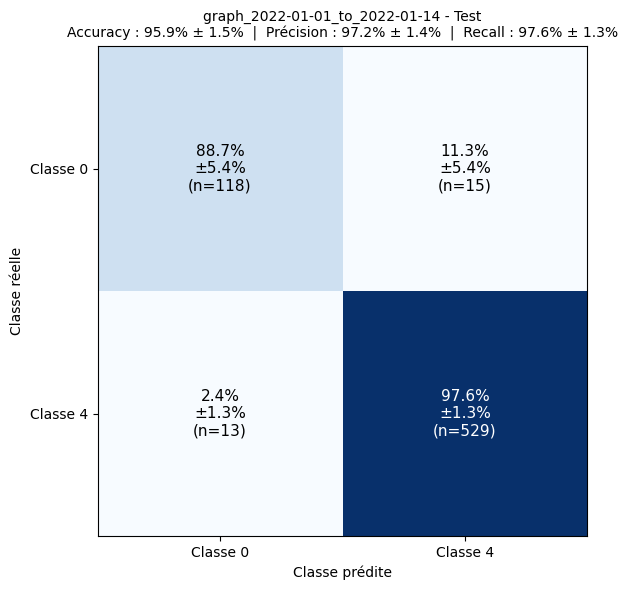

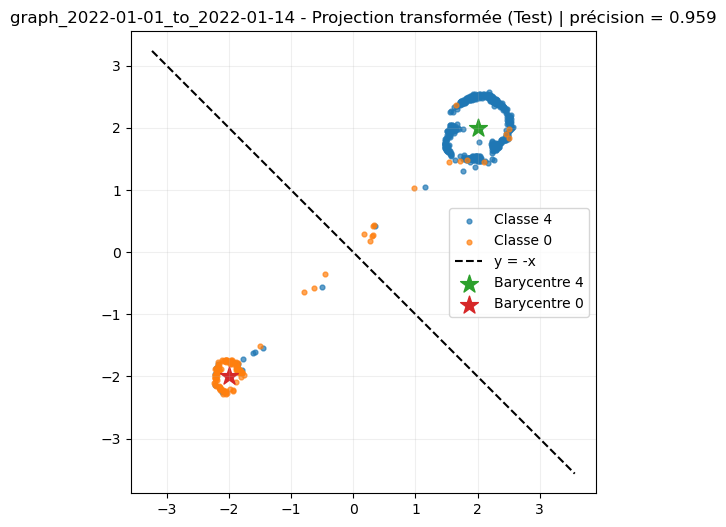


Traitement de graph_2022-01-01_to_2022-01-21
Train: 199 points
Test: 796 points

 Accuracy sur TRAIN: 0.9950 (99.50%)
 Accuracy sur TEST: 0.9698 (96.98%)

 Matrice de confusion sur TEST:


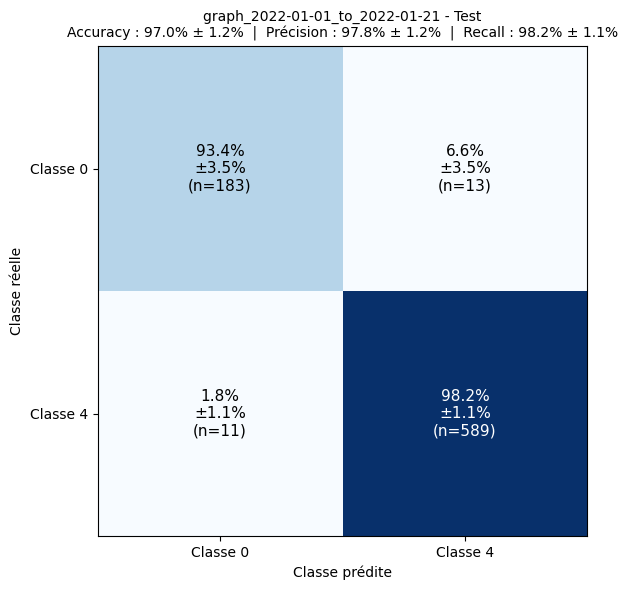

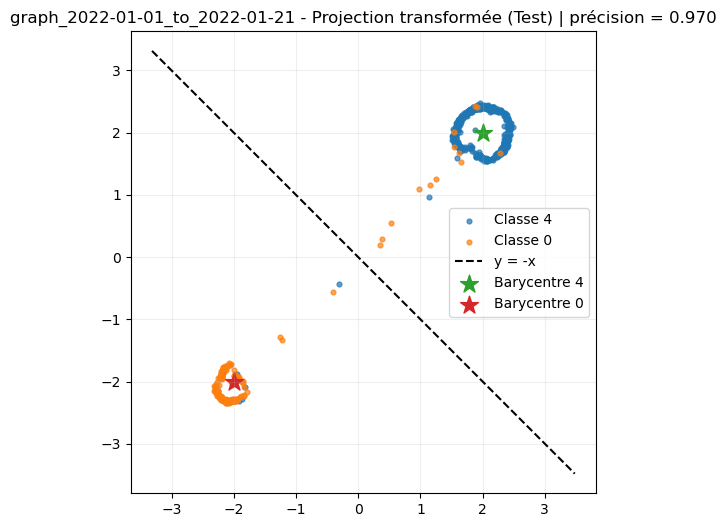


Traitement de graph_2022-01-08_to_2022-01-21
Train: 172 points
Test: 689 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9710 (97.10%)

 Matrice de confusion sur TEST:


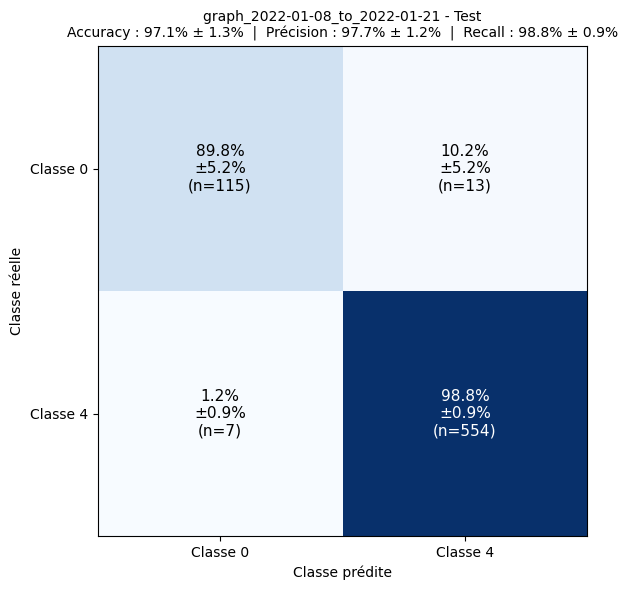

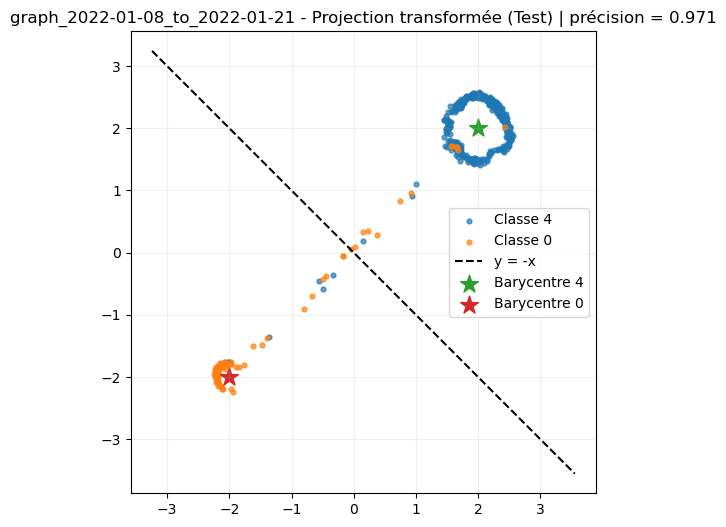


Traitement de graph_2022-01-08_to_2022-01-28
Train: 198 points
Test: 795 points

 Accuracy sur TRAIN: 0.9949 (99.49%)
 Accuracy sur TEST: 0.9686 (96.86%)

 Matrice de confusion sur TEST:


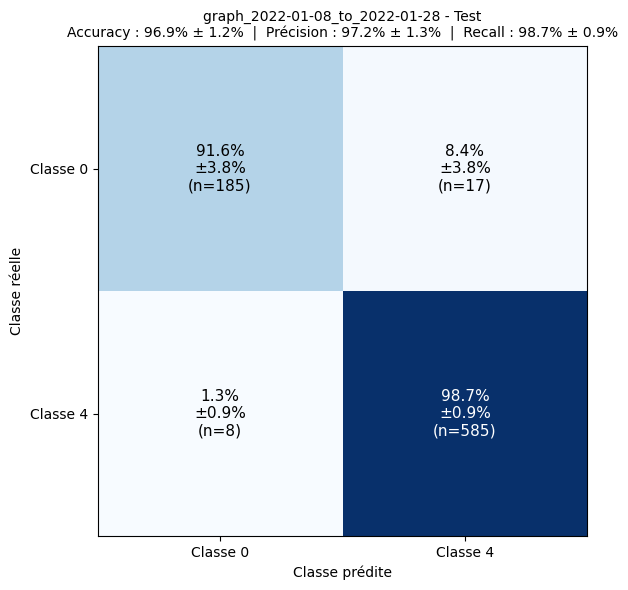

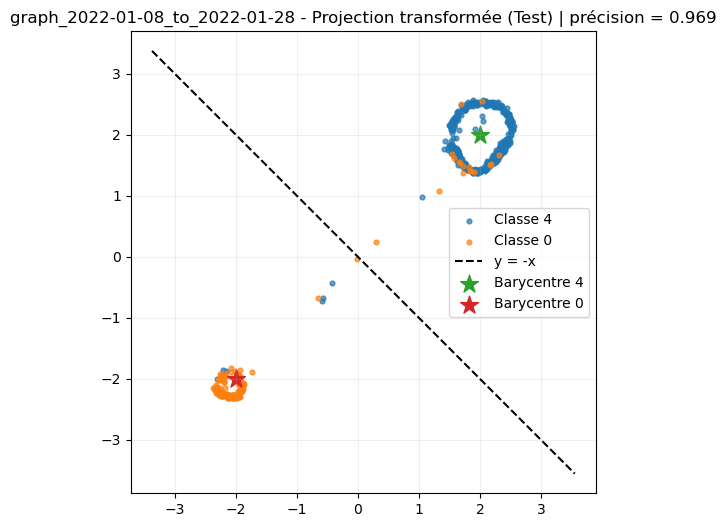


Traitement de graph_2022-01-15_to_2022-01-28
Train: 169 points
Test: 678 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9484 (94.84%)

 Matrice de confusion sur TEST:


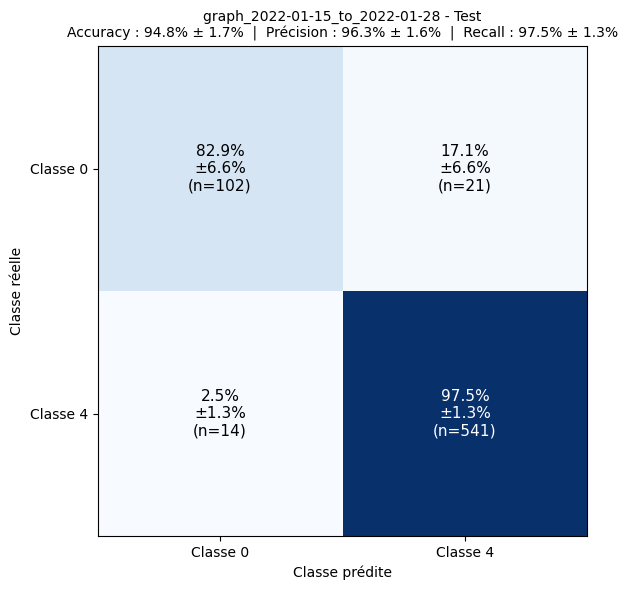

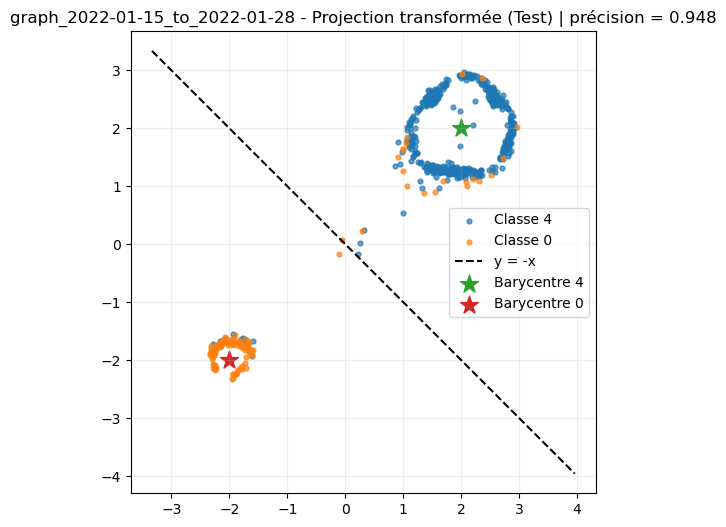


Traitement de graph_2022-01-15_to_2022-02-04
Train: 210 points
Test: 842 points

 Accuracy sur TRAIN: 0.9905 (99.05%)
 Accuracy sur TEST: 0.9715 (97.15%)

 Matrice de confusion sur TEST:


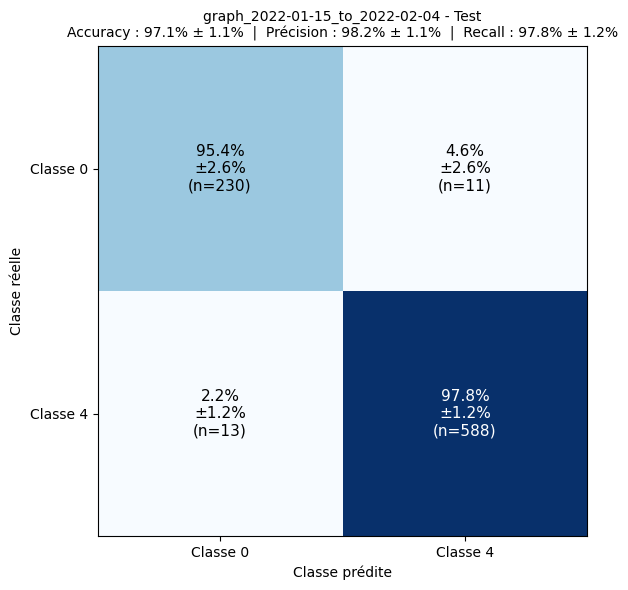

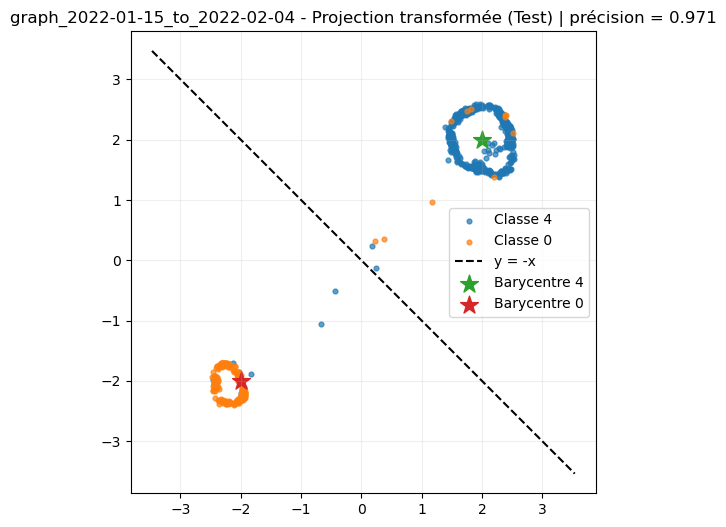


Traitement de graph_2022-01-22_to_2022-02-04
Train: 190 points
Test: 761 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9632 (96.32%)

 Matrice de confusion sur TEST:


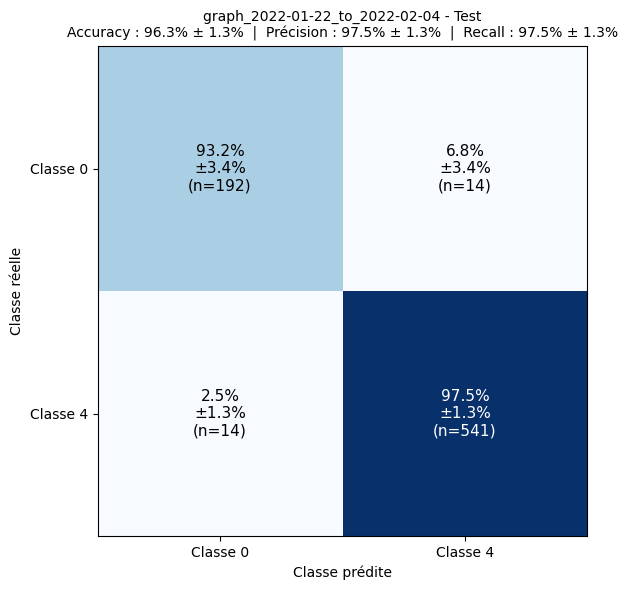

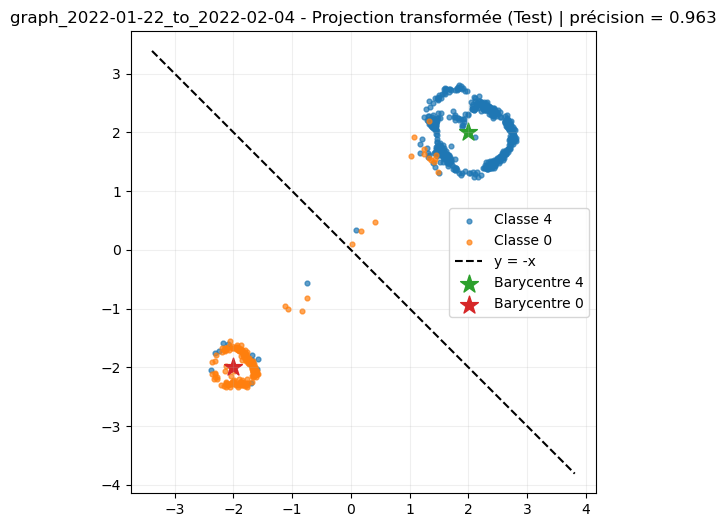


Traitement de graph_2022-01-22_to_2022-02-11
Train: 219 points
Test: 878 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9692 (96.92%)

 Matrice de confusion sur TEST:


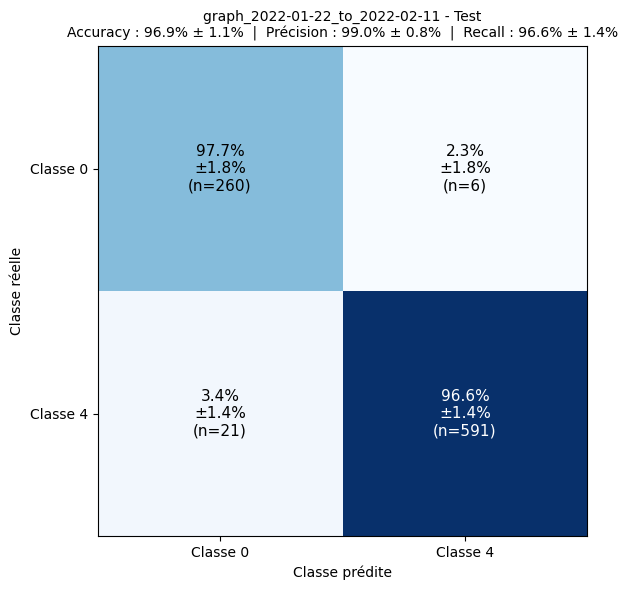

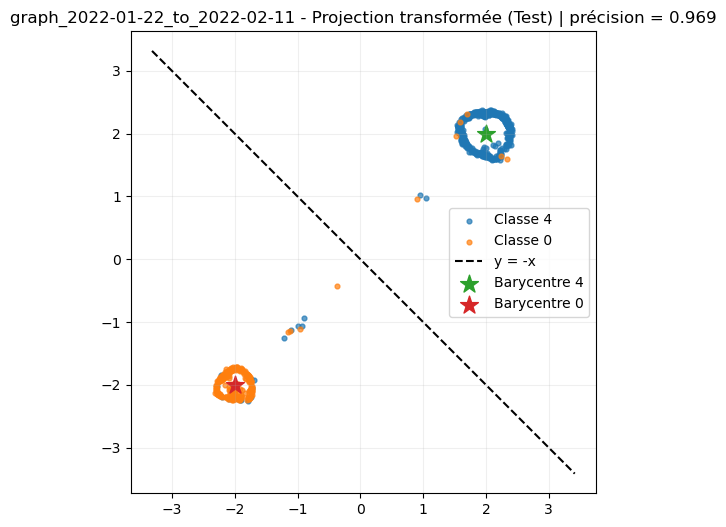


Traitement de graph_2022-01-29_to_2022-02-11
Train: 193 points
Test: 776 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9691 (96.91%)

 Matrice de confusion sur TEST:


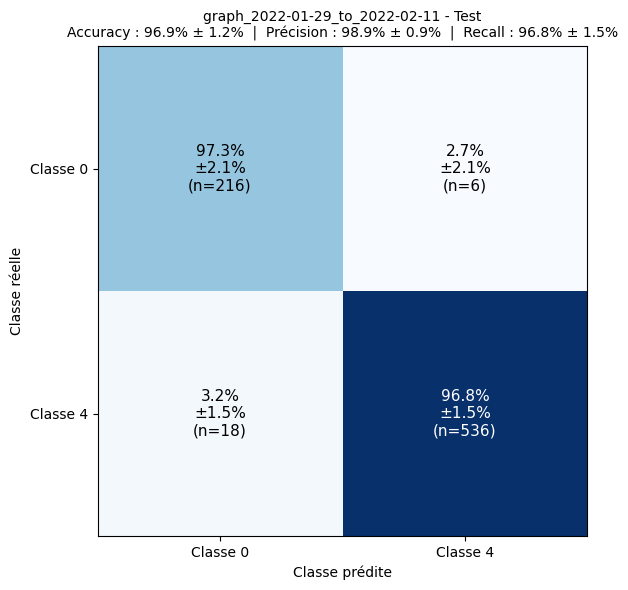

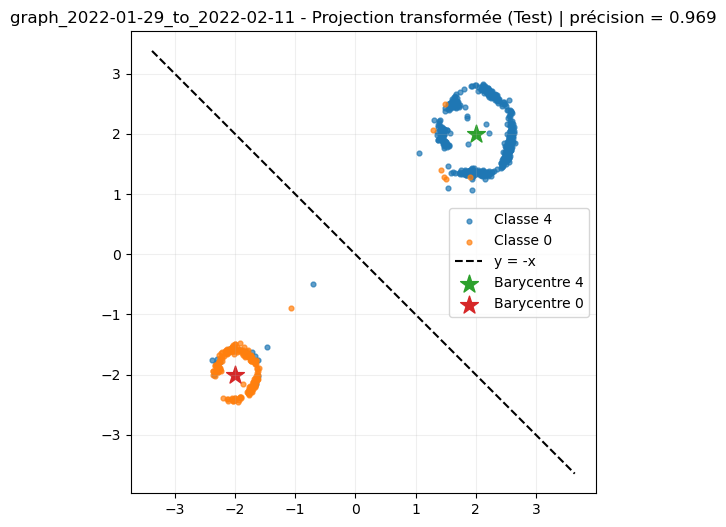


Traitement de graph_2022-01-29_to_2022-02-18
Train: 221 points
Test: 884 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9774 (97.74%)

 Matrice de confusion sur TEST:


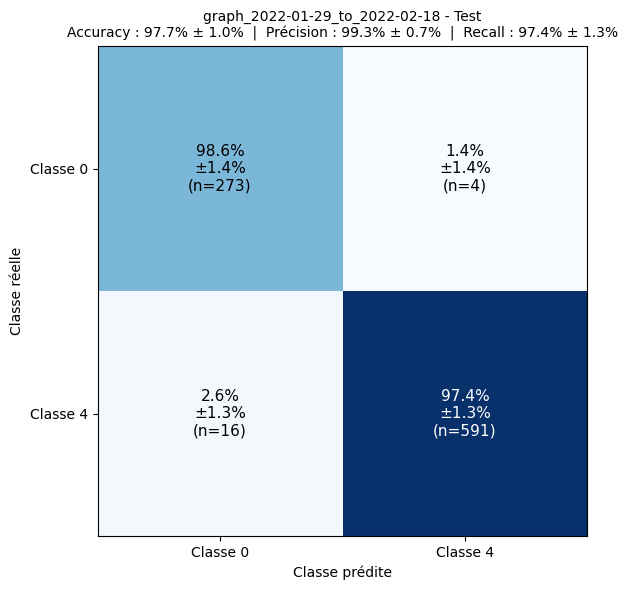

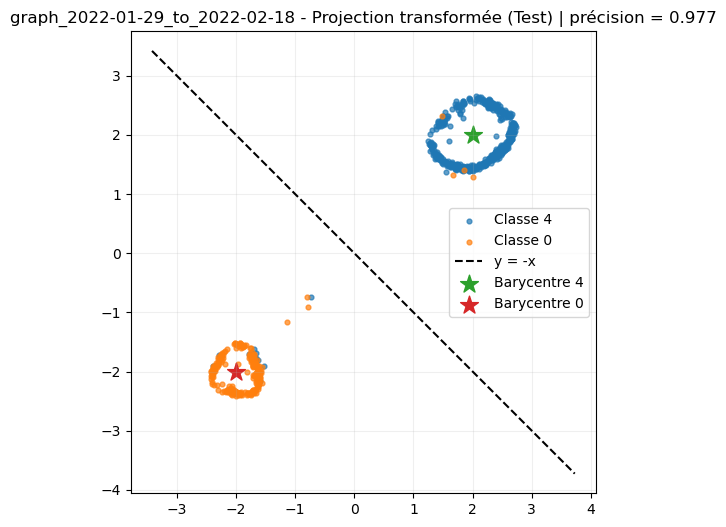


Traitement de graph_2022-02-05_to_2022-02-18
Train: 181 points
Test: 727 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9560 (95.60%)

 Matrice de confusion sur TEST:


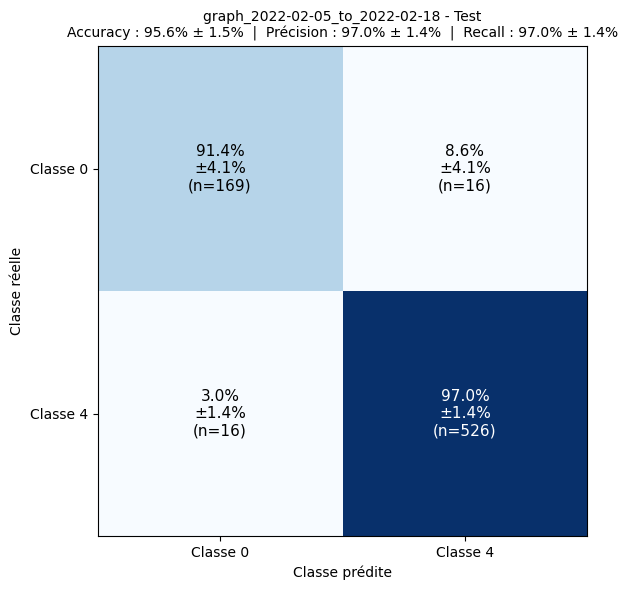

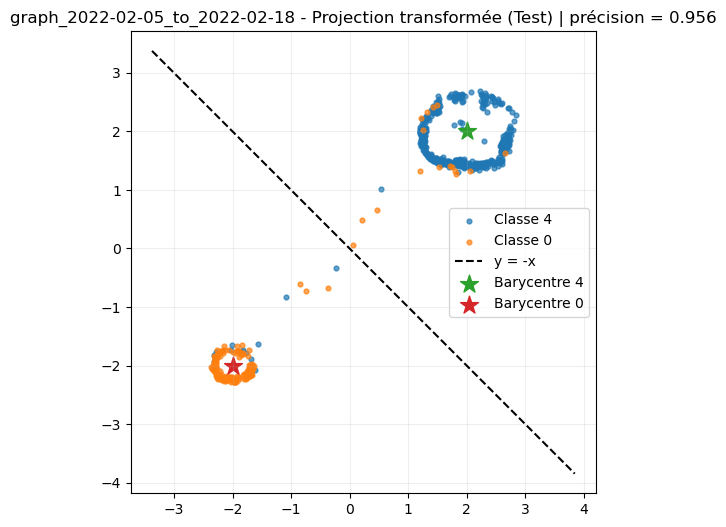


Traitement de graph_2022-02-05_to_2022-02-25
Train: 223 points
Test: 894 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9765 (97.65%)

 Matrice de confusion sur TEST:


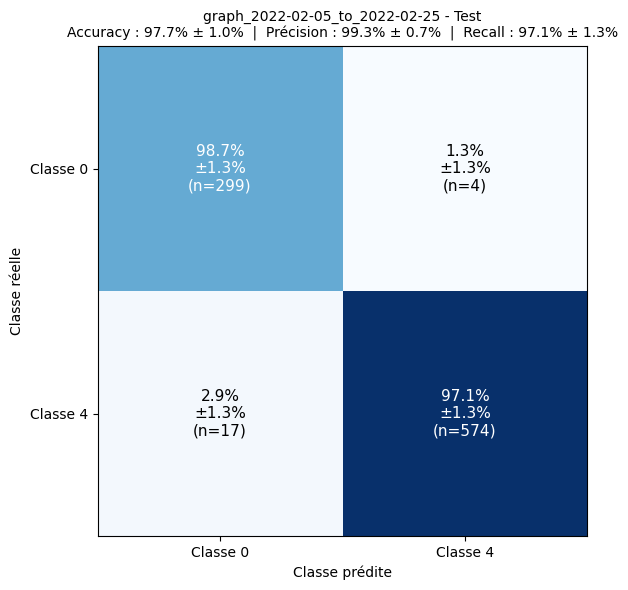

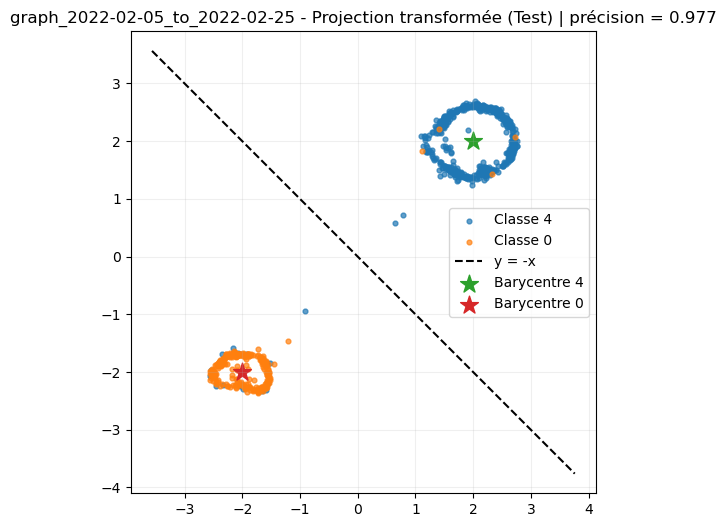


Traitement de graph_2022-02-12_to_2022-02-25
Train: 191 points
Test: 765 points

 Accuracy sur TRAIN: 0.9948 (99.48%)
 Accuracy sur TEST: 0.9608 (96.08%)

 Matrice de confusion sur TEST:


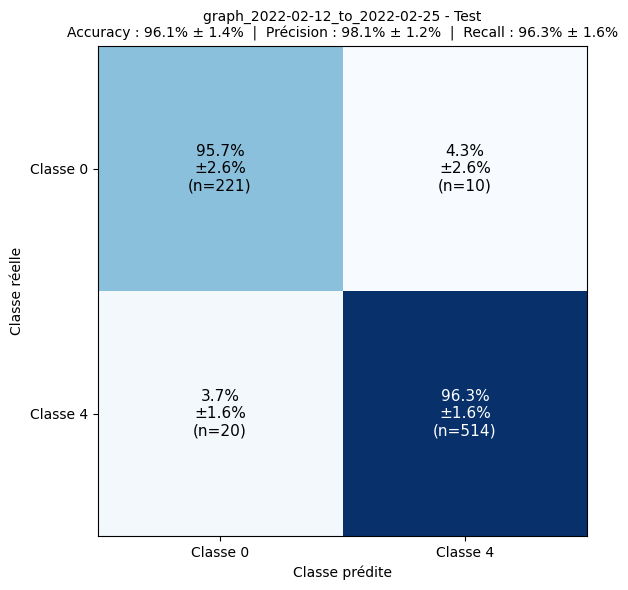

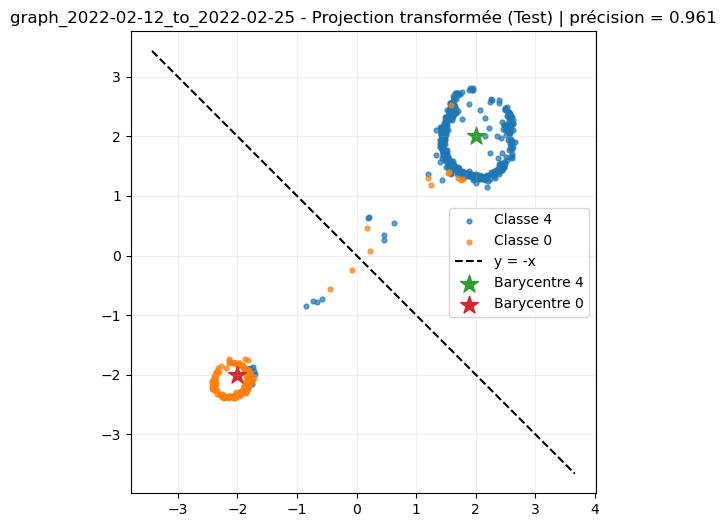


Traitement de graph_2022-02-12_to_2022-03-04
Train: 233 points
Test: 932 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9753 (97.53%)

 Matrice de confusion sur TEST:


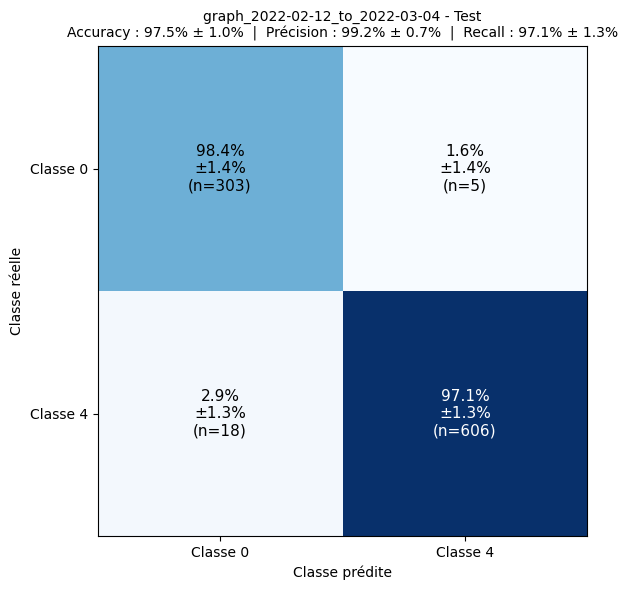

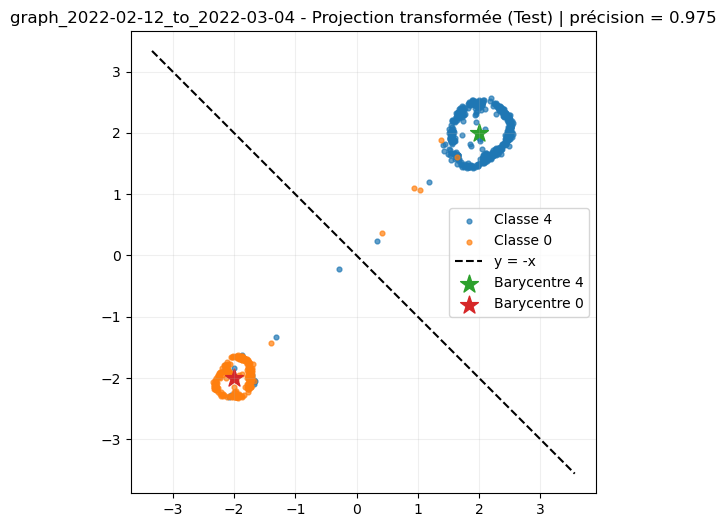


Traitement de graph_2022-02-19_to_2022-03-04
Train: 208 points
Test: 832 points

 Accuracy sur TRAIN: 0.9856 (98.56%)
 Accuracy sur TEST: 0.9579 (95.79%)

 Matrice de confusion sur TEST:


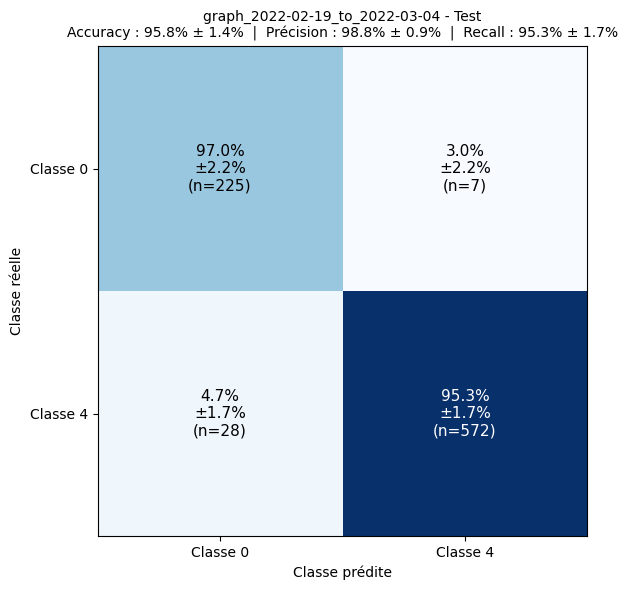

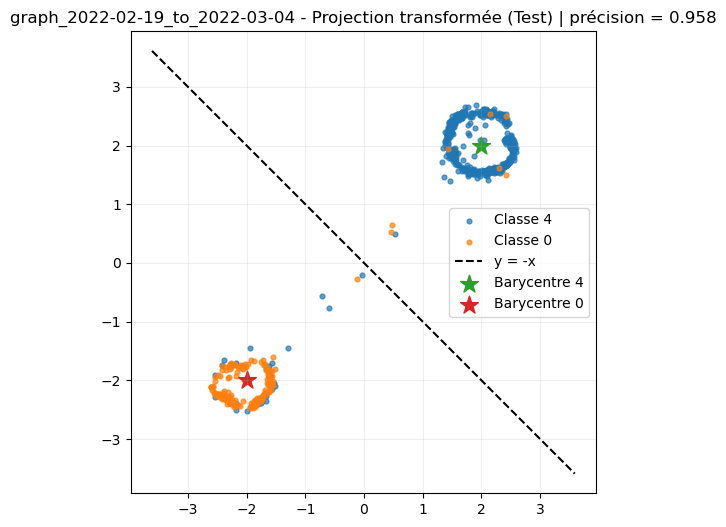


Traitement de graph_2022-02-19_to_2022-03-11
Train: 245 points
Test: 980 points

 Accuracy sur TRAIN: 0.9959 (99.59%)
 Accuracy sur TEST: 0.9776 (97.76%)

 Matrice de confusion sur TEST:


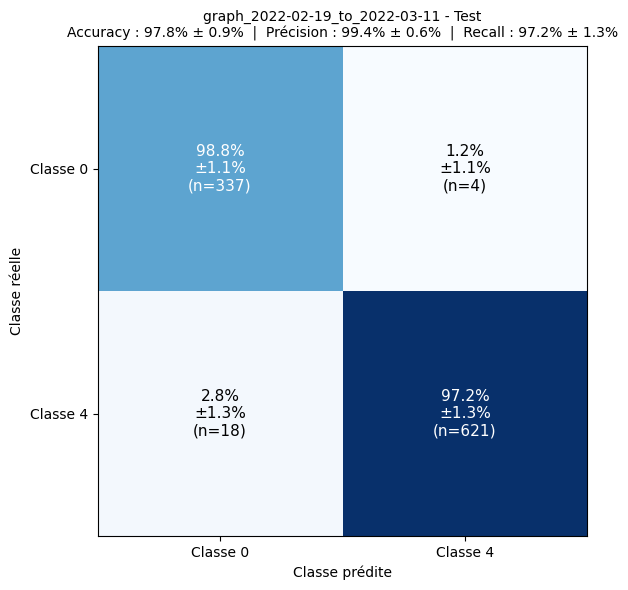

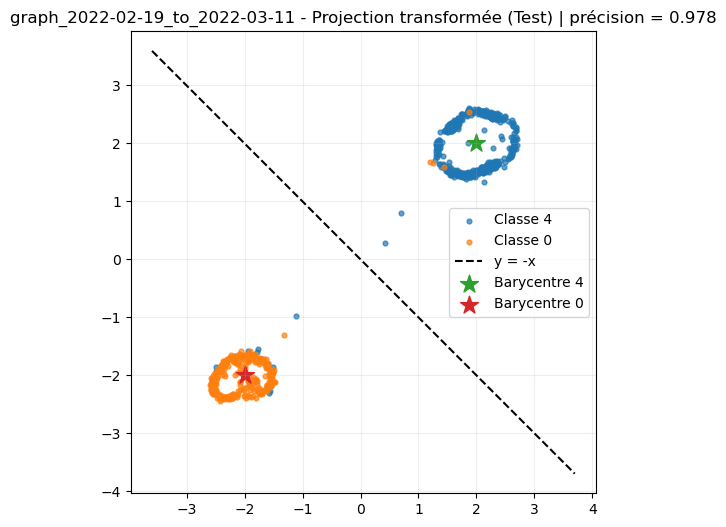


Traitement de graph_2022-02-26_to_2022-03-11
Train: 214 points
Test: 858 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9685 (96.85%)

 Matrice de confusion sur TEST:


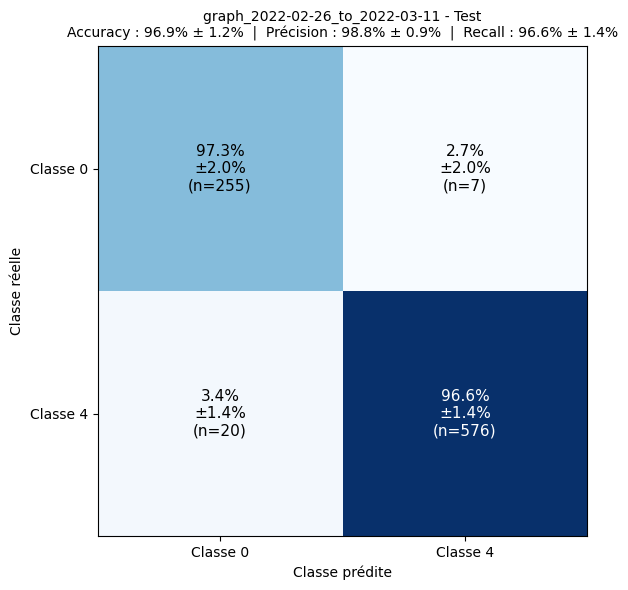

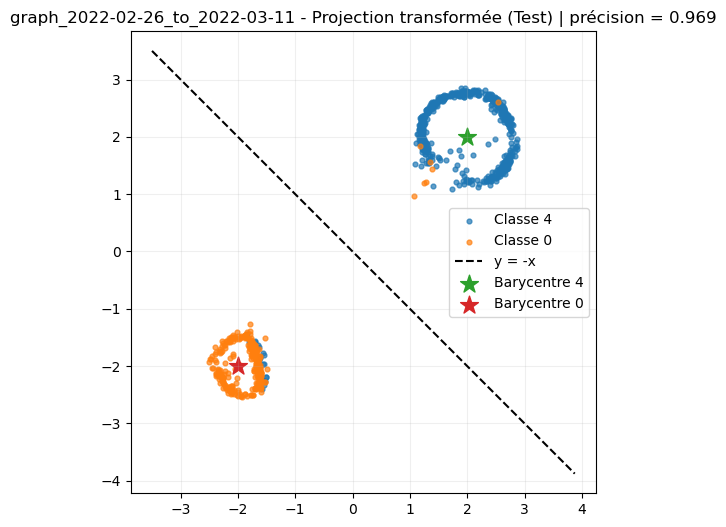


Traitement de graph_2022-02-26_to_2022-03-18
Train: 243 points
Test: 974 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9836 (98.36%)

 Matrice de confusion sur TEST:


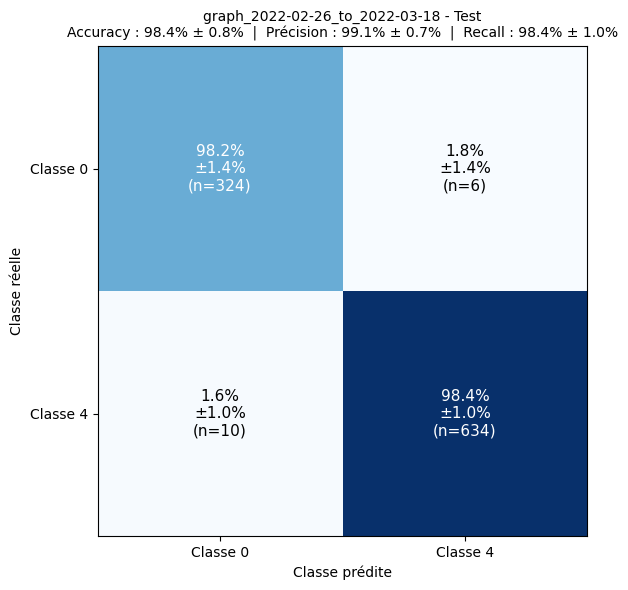

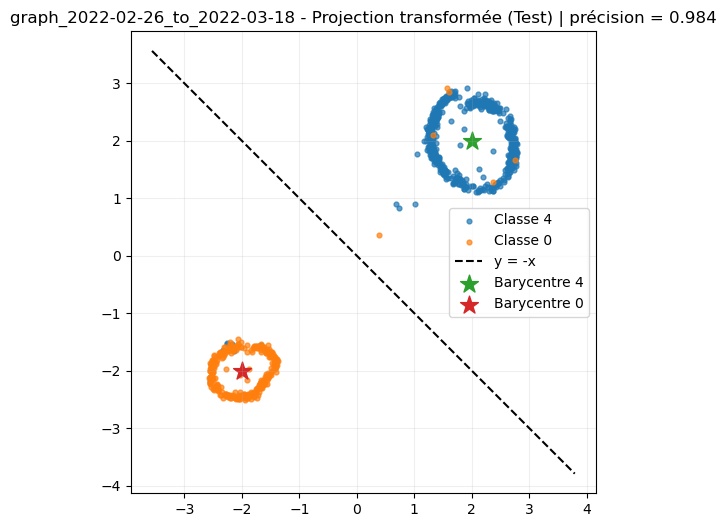


Traitement de graph_2022-03-05_to_2022-03-25
Train: 237 points
Test: 950 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9821 (98.21%)

 Matrice de confusion sur TEST:


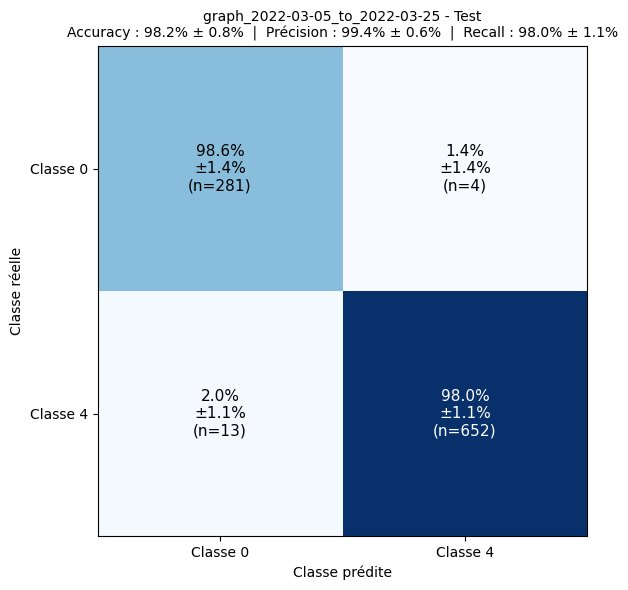

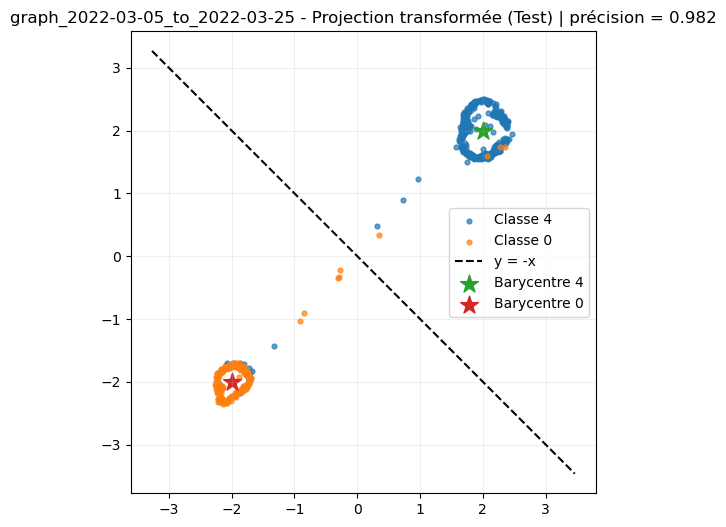


Traitement de graph_2022-03-12_to_2022-04-01
Train: 233 points
Test: 932 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9667 (96.67%)

 Matrice de confusion sur TEST:


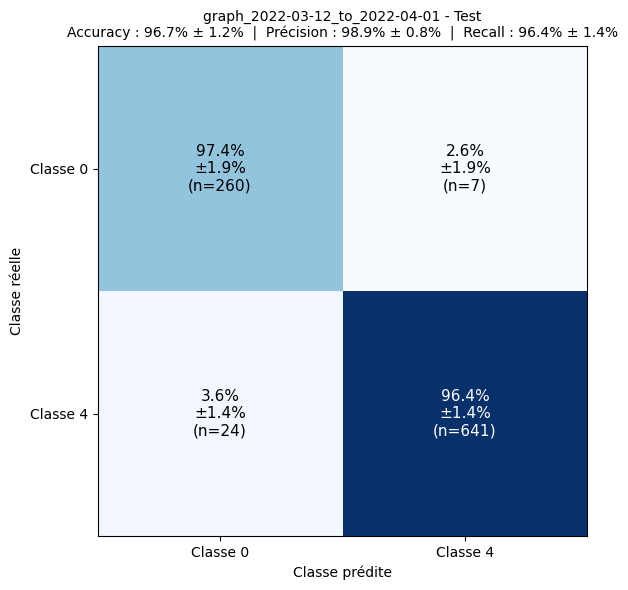

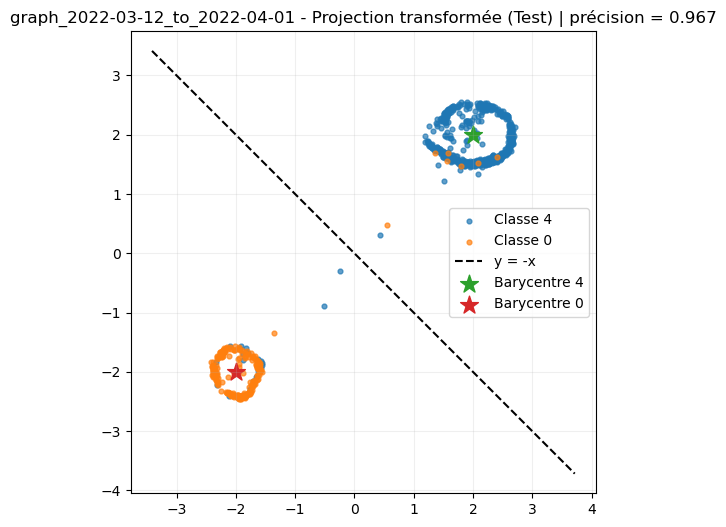


Traitement de graph_2022-03-19_to_2022-04-08
Train: 228 points
Test: 912 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9803 (98.03%)

 Matrice de confusion sur TEST:


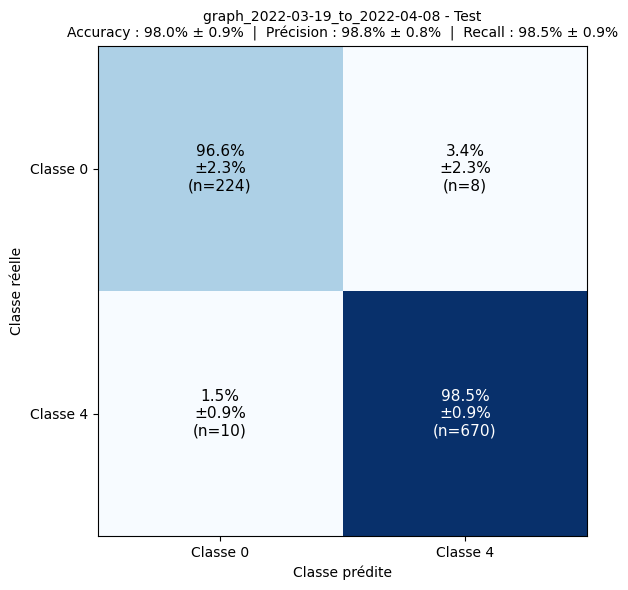

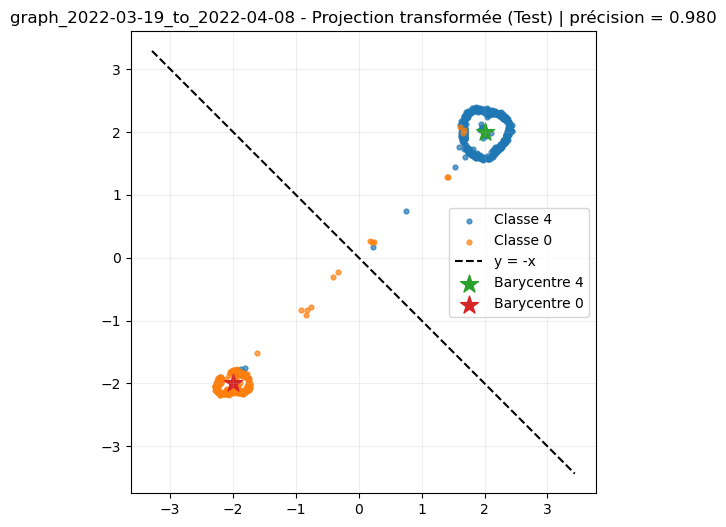


Traitement de graph_2022-03-26_to_2022-04-15
Train: 228 points
Test: 916 points

 Accuracy sur TRAIN: 0.9912 (99.12%)
 Accuracy sur TEST: 0.9705 (97.05%)

 Matrice de confusion sur TEST:


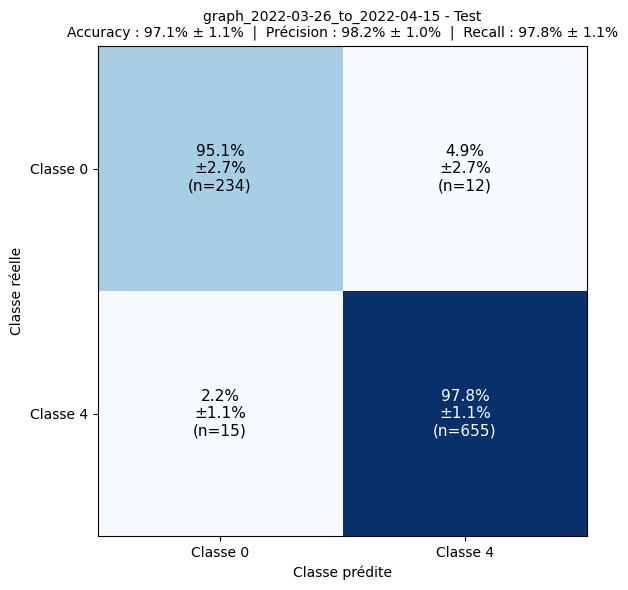

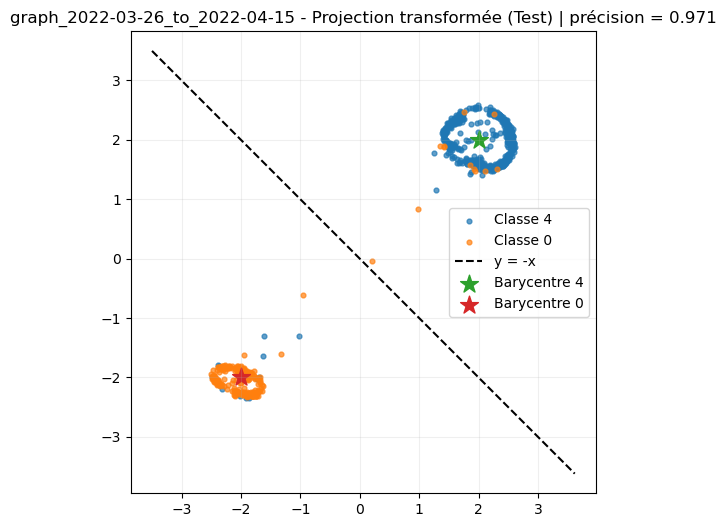


Traitement de graph_2022-04-02_to_2022-04-22
Train: 219 points
Test: 877 points

 Accuracy sur TRAIN: 0.9954 (99.54%)
 Accuracy sur TEST: 0.9669 (96.69%)

 Matrice de confusion sur TEST:


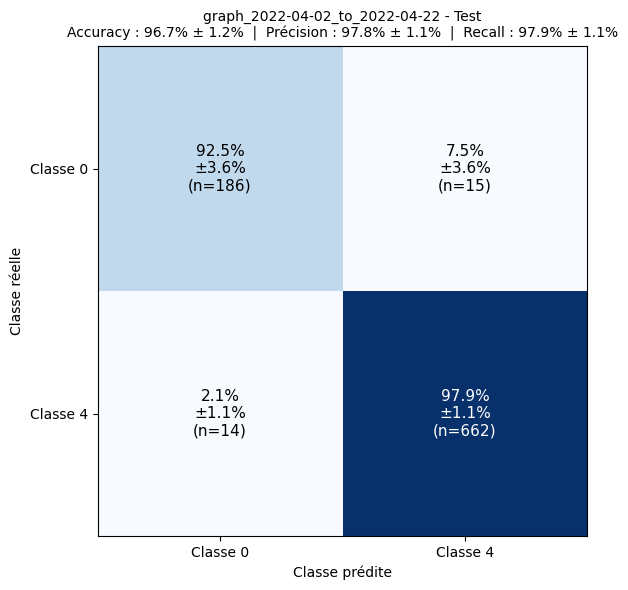

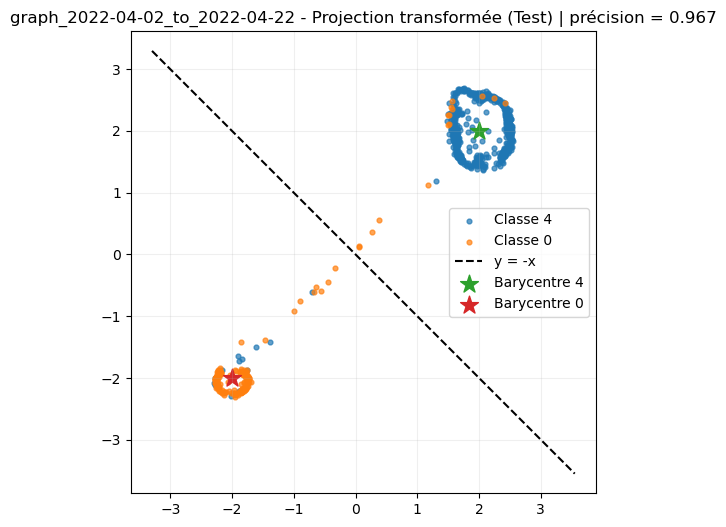


Traitement de graph_2022-04-09_to_2022-04-29
Train: 242 points
Test: 968 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9793 (97.93%)

 Matrice de confusion sur TEST:


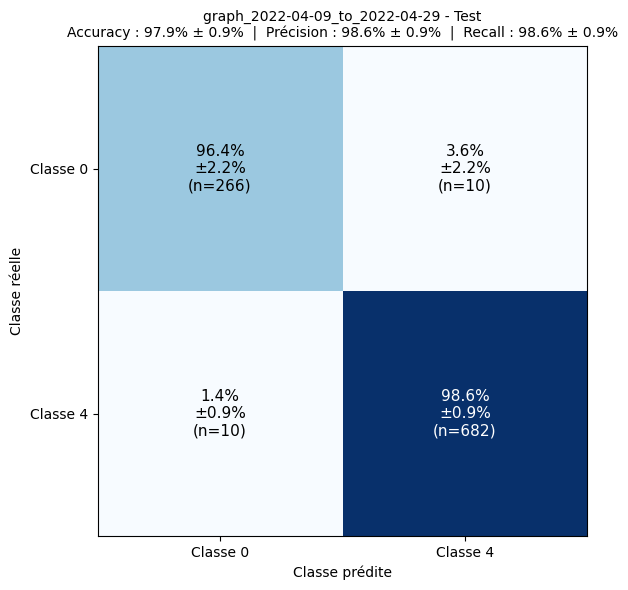

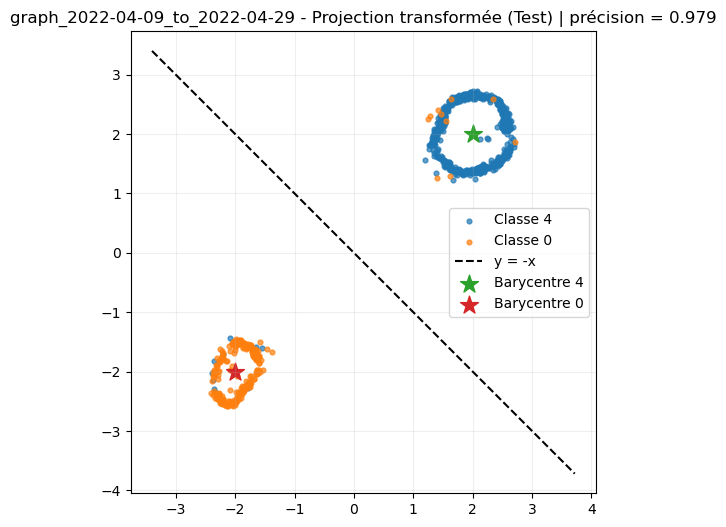


Traitement de graph_2022-04-16_to_2022-05-06
Train: 252 points
Test: 1008 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9831 (98.31%)

 Matrice de confusion sur TEST:


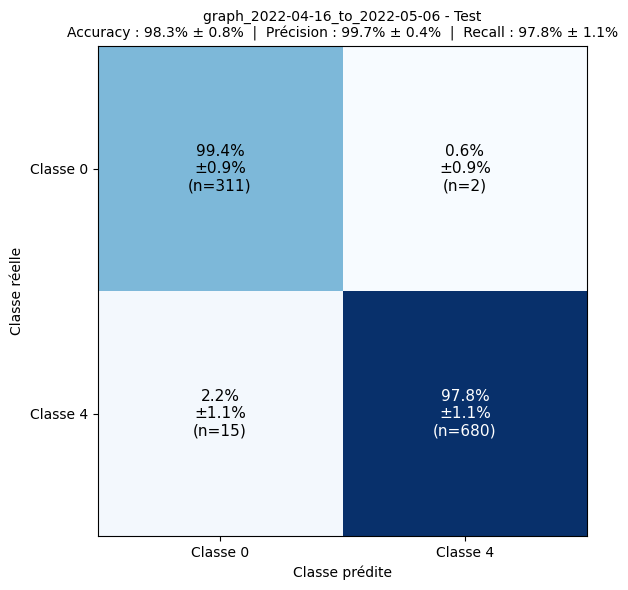

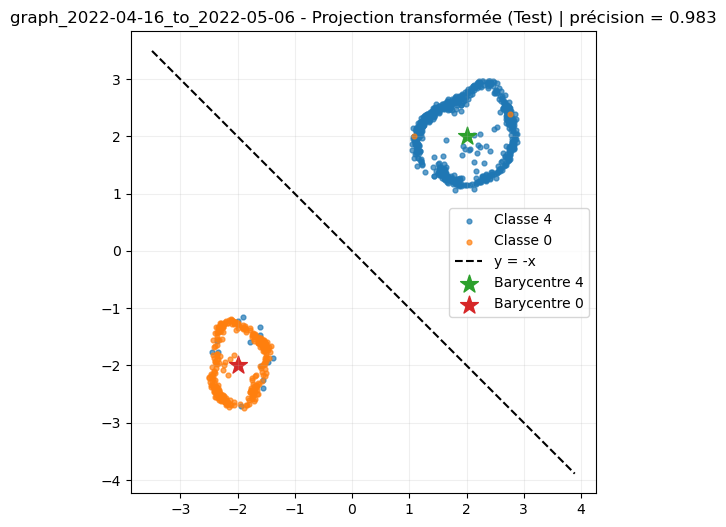


Traitement de graph_2022-04-23_to_2022-05-13
Train: 265 points
Test: 1063 points

 Accuracy sur TRAIN: 0.9962 (99.62%)
 Accuracy sur TEST: 0.9878 (98.78%)

 Matrice de confusion sur TEST:


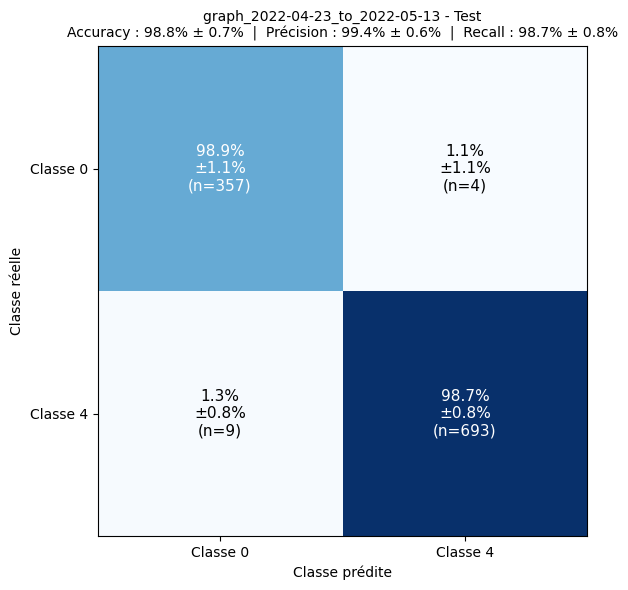

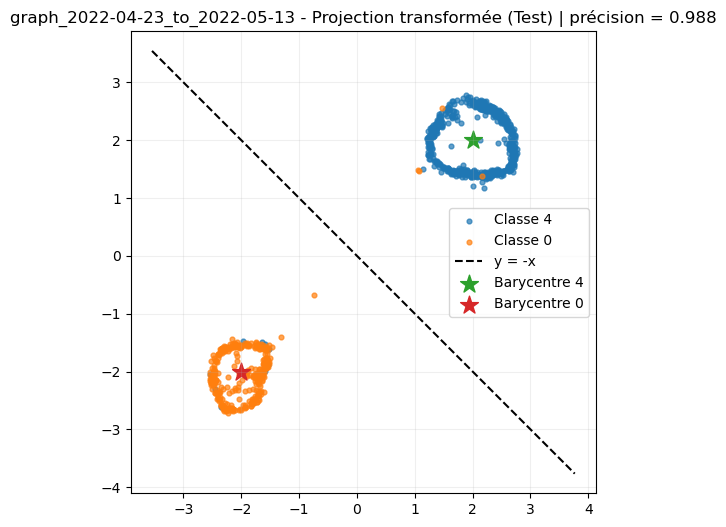


Traitement de graph_2022-04-30_to_2022-05-20
Train: 249 points
Test: 996 points

 Accuracy sur TRAIN: 0.9960 (99.60%)
 Accuracy sur TEST: 0.9779 (97.79%)

 Matrice de confusion sur TEST:


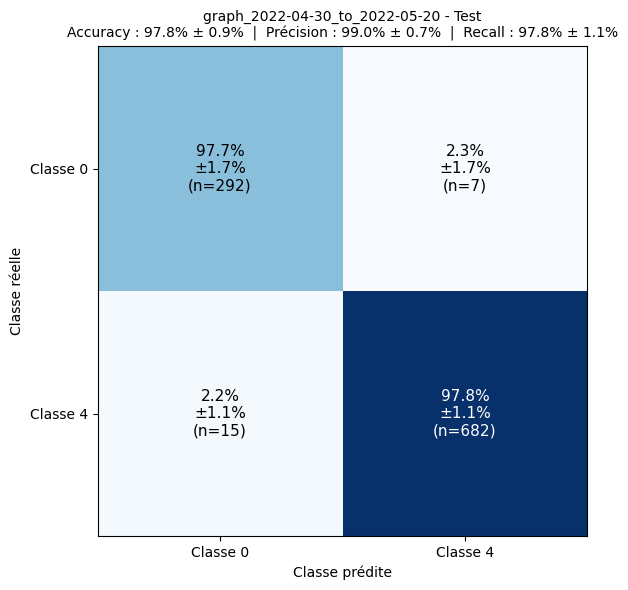

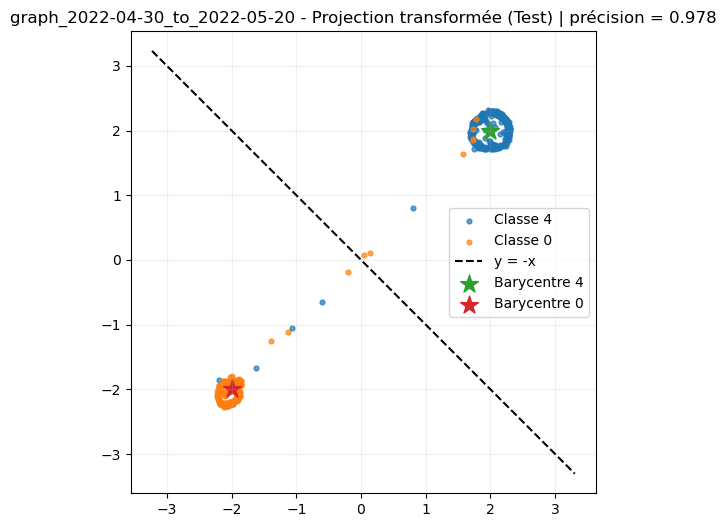


Traitement de graph_2022-05-07_to_2022-05-27
Train: 280 points
Test: 1121 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9831 (98.31%)

 Matrice de confusion sur TEST:


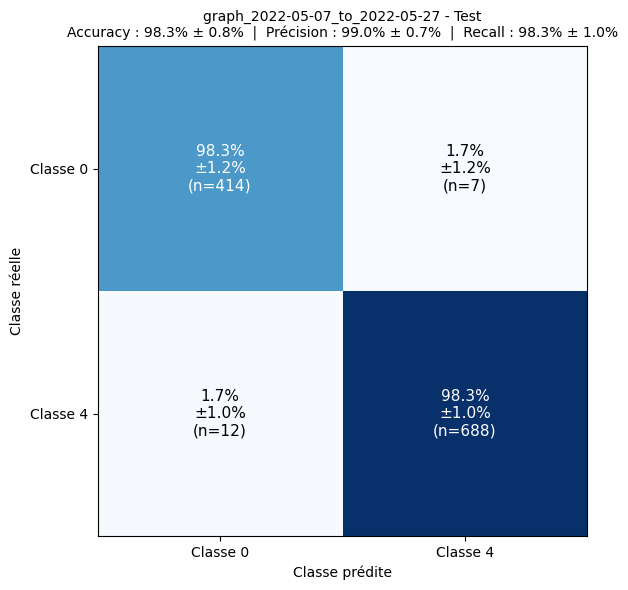

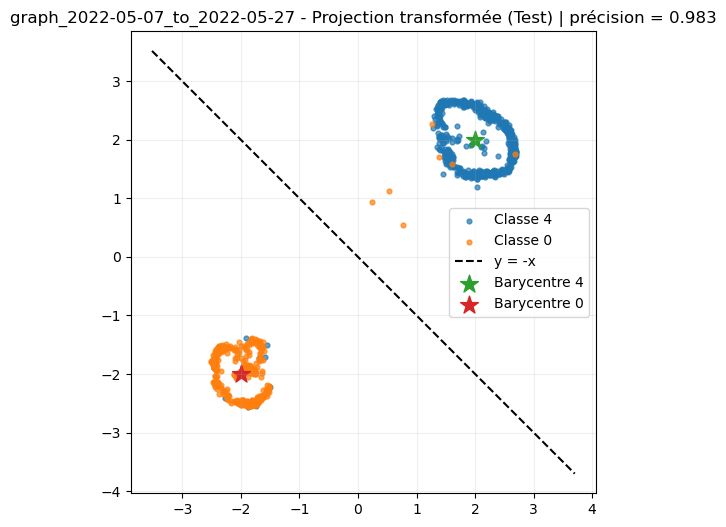


Traitement de graph_2022-05-14_to_2022-06-03
Train: 281 points
Test: 1126 points

 Accuracy sur TRAIN: 0.9893 (98.93%)
 Accuracy sur TEST: 0.9858 (98.58%)

 Matrice de confusion sur TEST:


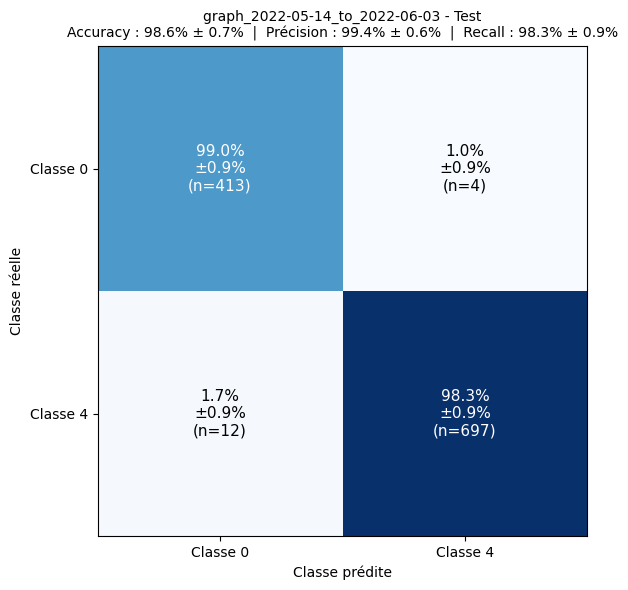

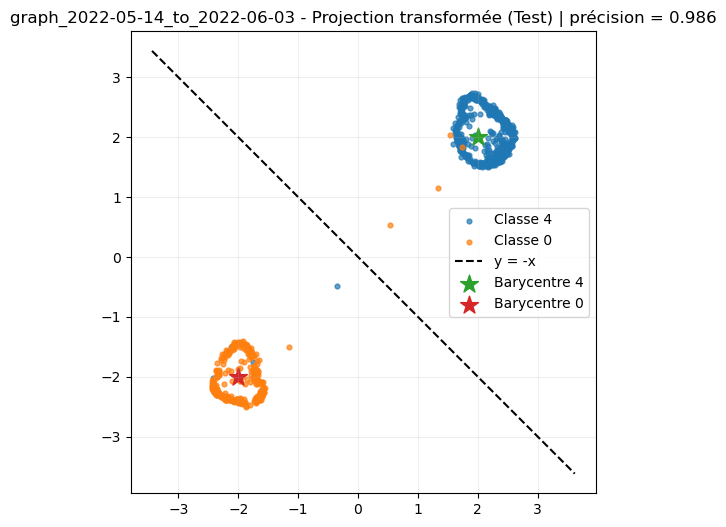


Traitement de graph_2022-05-21_to_2022-06-10
Train: 294 points
Test: 1178 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9864 (98.64%)

 Matrice de confusion sur TEST:


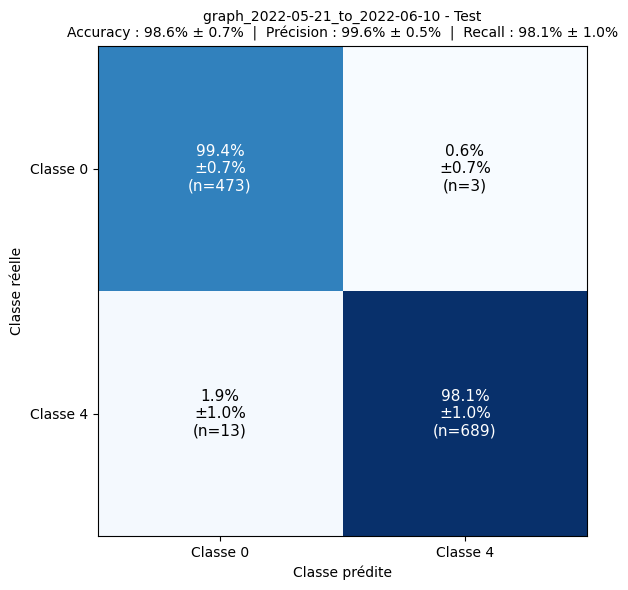

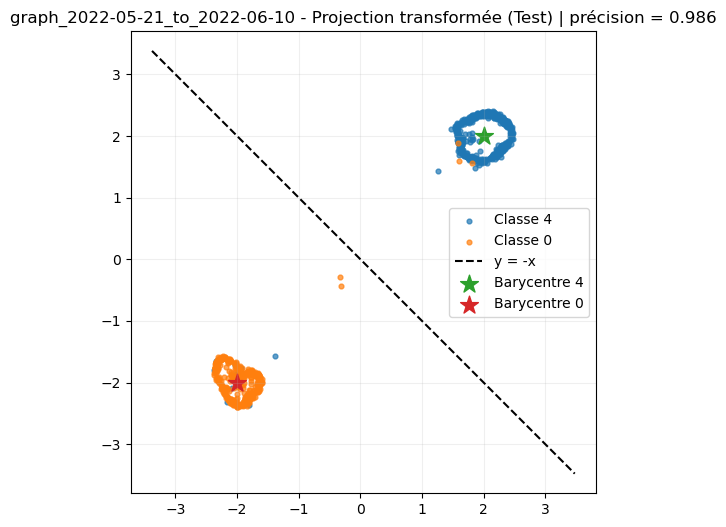


Traitement de graph_2022-05-28_to_2022-06-17
Train: 304 points
Test: 1216 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9811 (98.11%)

 Matrice de confusion sur TEST:


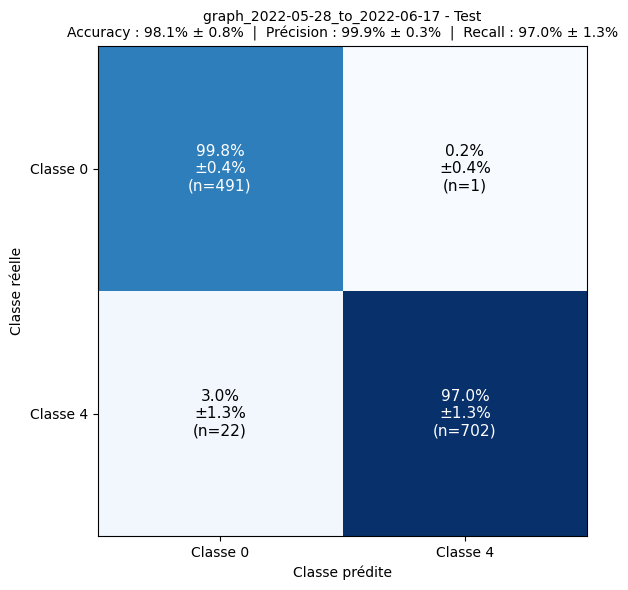

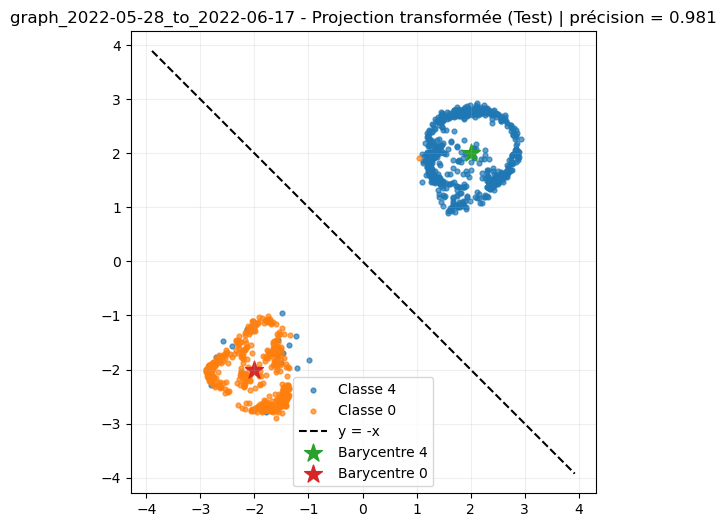


Traitement de graph_2022-06-04_to_2022-06-24
Train: 315 points
Test: 1261 points

 Accuracy sur TRAIN: 0.9968 (99.68%)
 Accuracy sur TEST: 0.9857 (98.57%)

 Matrice de confusion sur TEST:


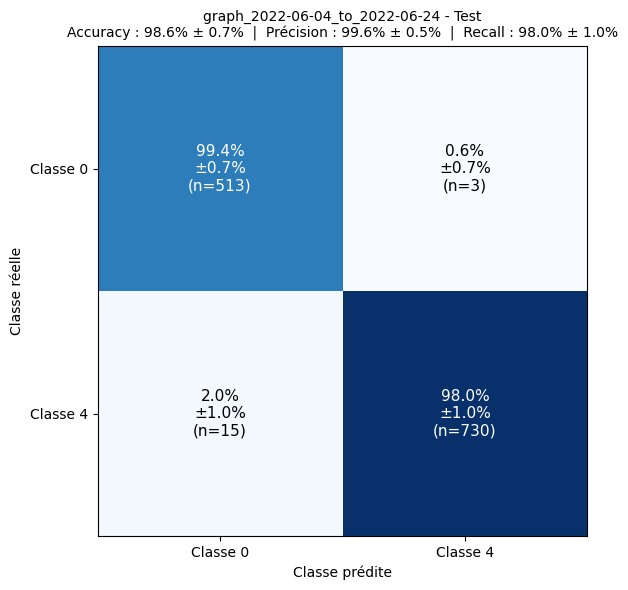

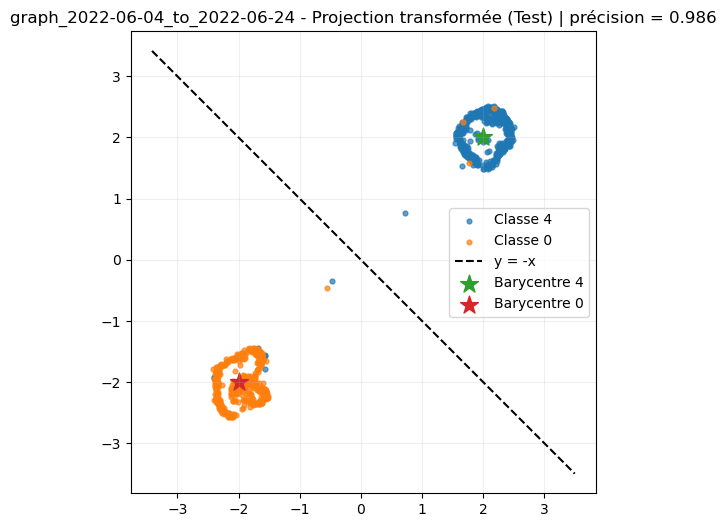


Traitement de graph_2022-06-11_to_2022-07-01
Train: 336 points
Test: 1348 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9904 (99.04%)

 Matrice de confusion sur TEST:


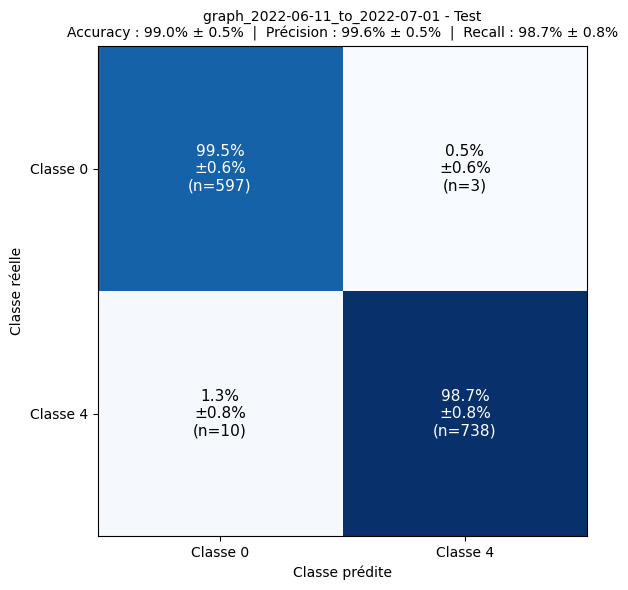

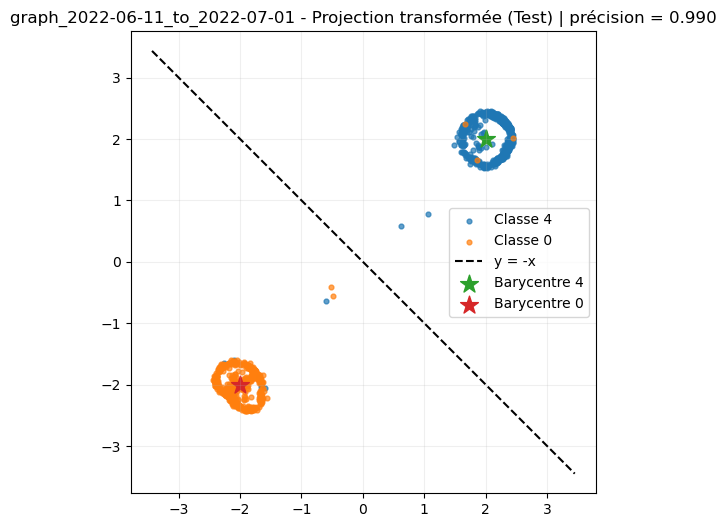


Traitement de graph_2022-06-18_to_2022-07-08
Train: 354 points
Test: 1420 points

 Accuracy sur TRAIN: 0.9972 (99.72%)
 Accuracy sur TEST: 0.9923 (99.23%)

 Matrice de confusion sur TEST:


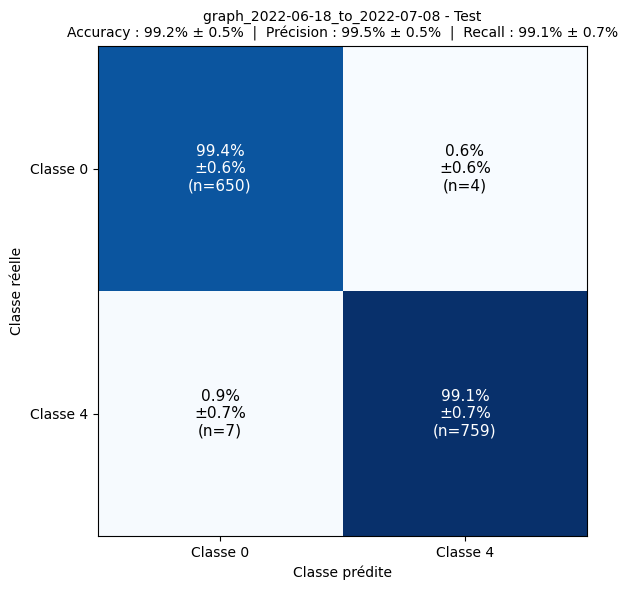

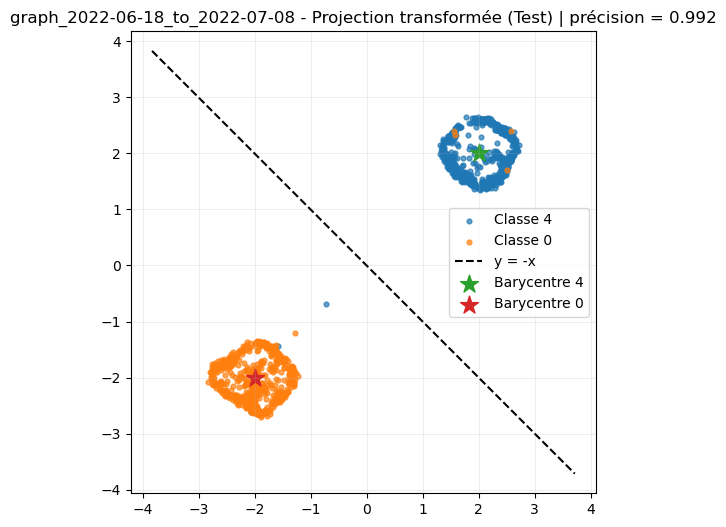


Traitement de graph_2022-06-25_to_2022-07-15
Train: 378 points
Test: 1515 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9934 (99.34%)

 Matrice de confusion sur TEST:


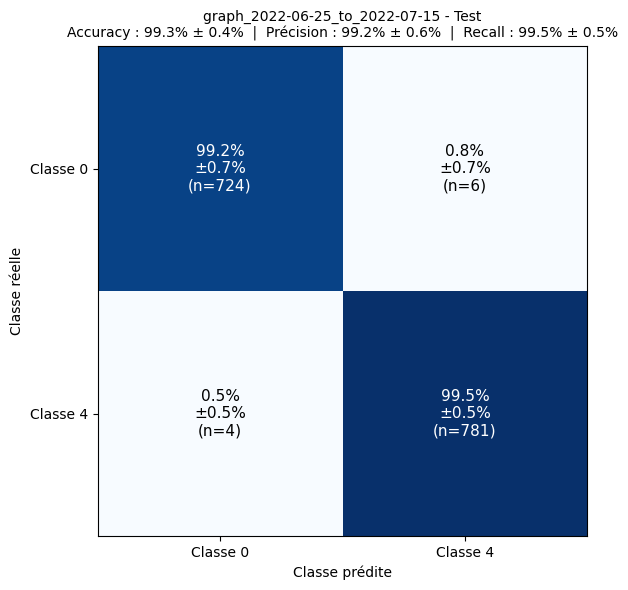

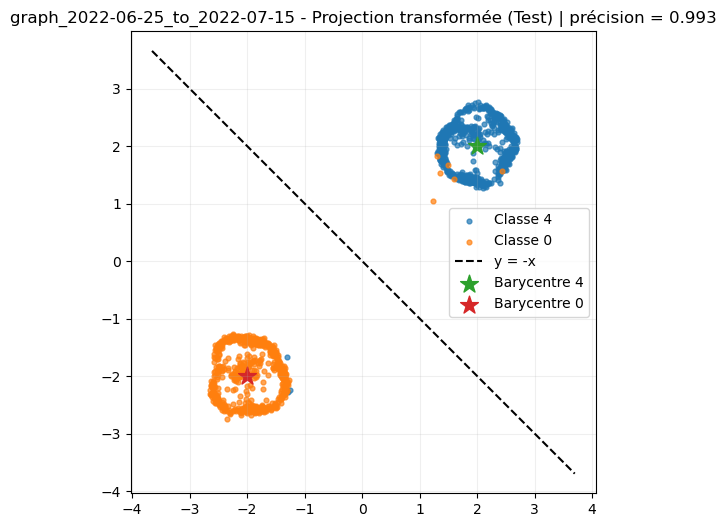


Traitement de graph_2022-07-02_to_2022-07-22
Train: 400 points
Test: 1600 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 1.0000 (100.00%)

 Matrice de confusion sur TEST:


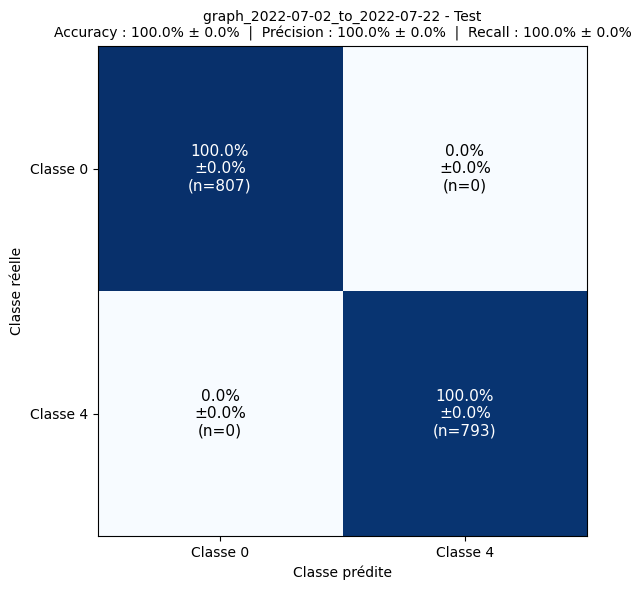

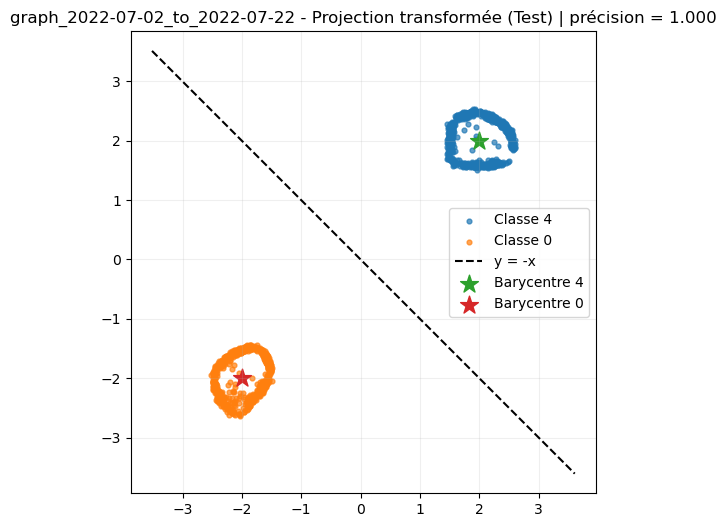


Traitement de graph_2022-07-09_to_2022-07-29
Train: 399 points
Test: 1596 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9994 (99.94%)

 Matrice de confusion sur TEST:


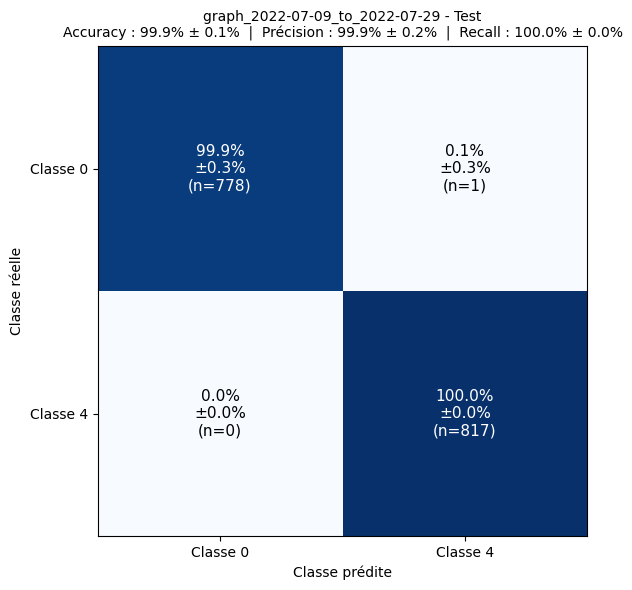

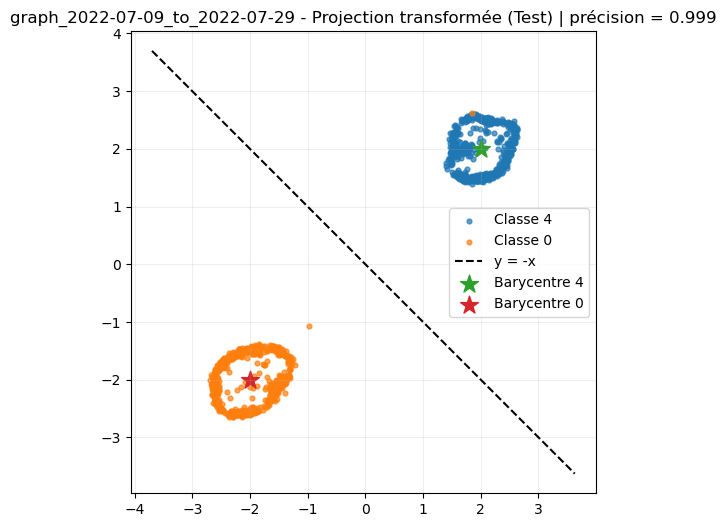


Traitement de graph_2022-07-16_to_2022-08-05
Train: 394 points
Test: 1579 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9975 (99.75%)

 Matrice de confusion sur TEST:


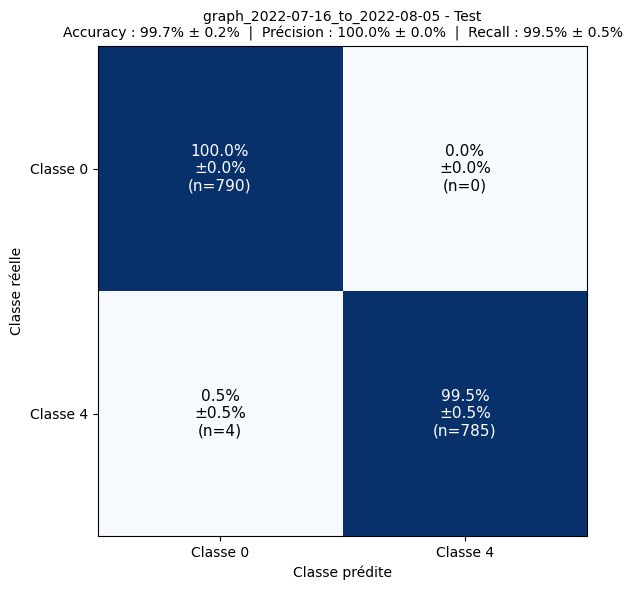

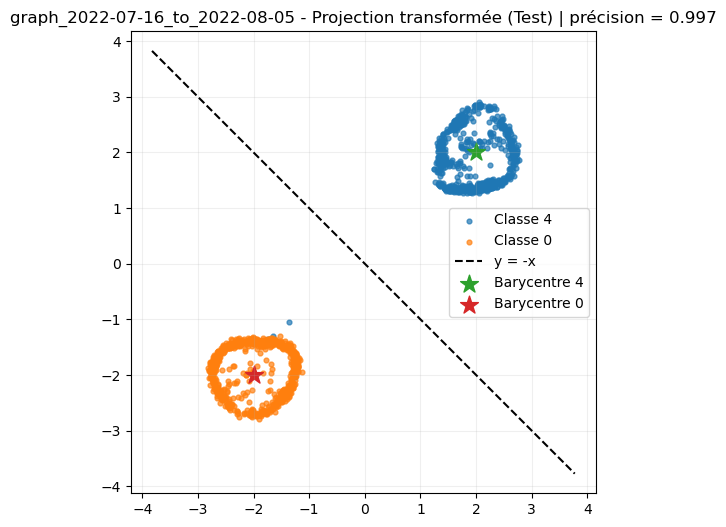


Traitement de graph_2022-07-23_to_2022-08-12
Train: 375 points
Test: 1500 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9947 (99.47%)

 Matrice de confusion sur TEST:


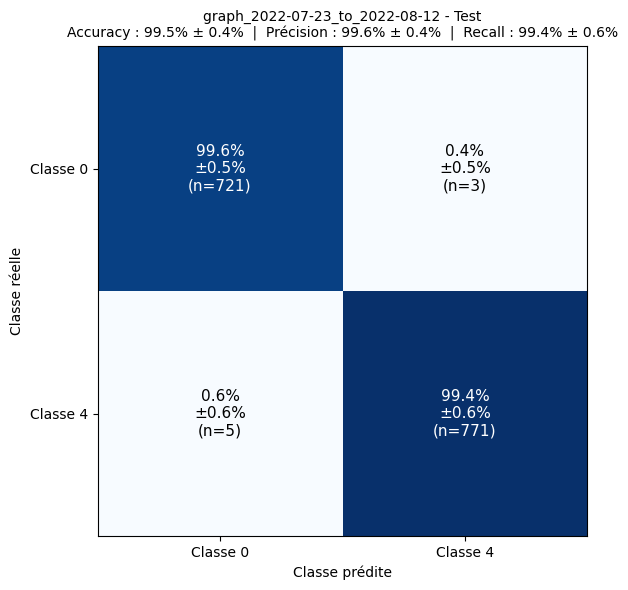

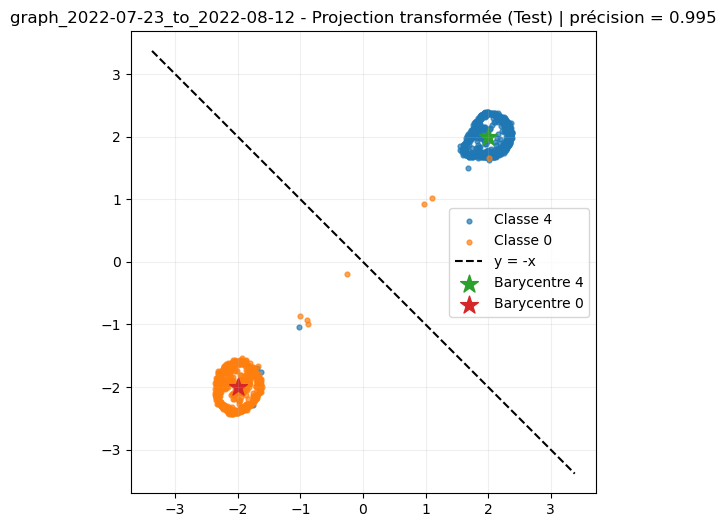


Traitement de graph_2022-07-30_to_2022-08-19
Train: 353 points
Test: 1414 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9915 (99.15%)

 Matrice de confusion sur TEST:


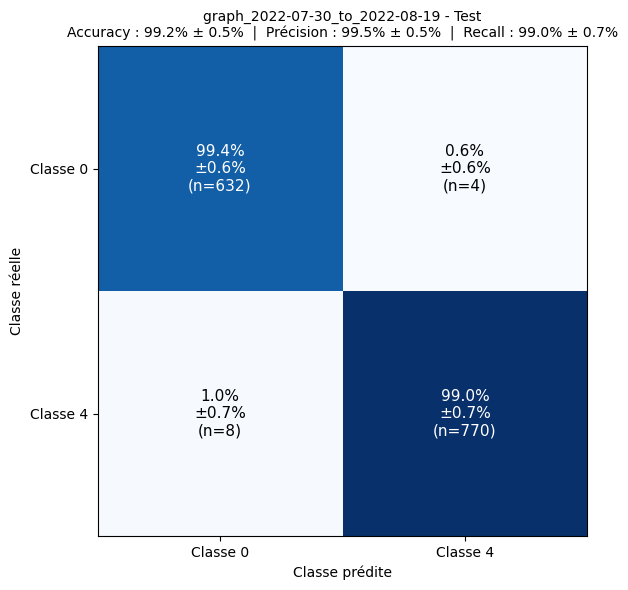

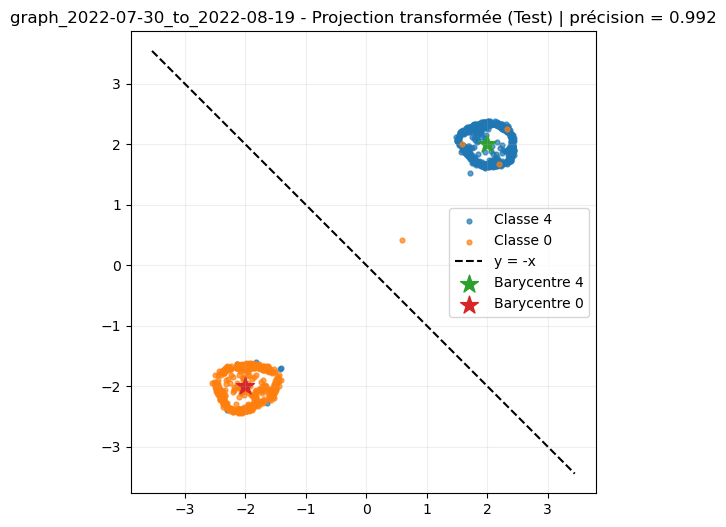


Traitement de graph_2022-08-06_to_2022-08-26
Train: 340 points
Test: 1363 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9919 (99.19%)

 Matrice de confusion sur TEST:


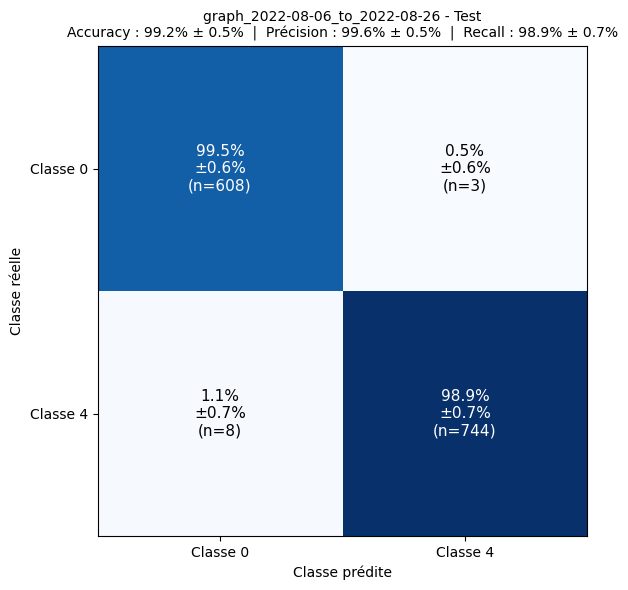

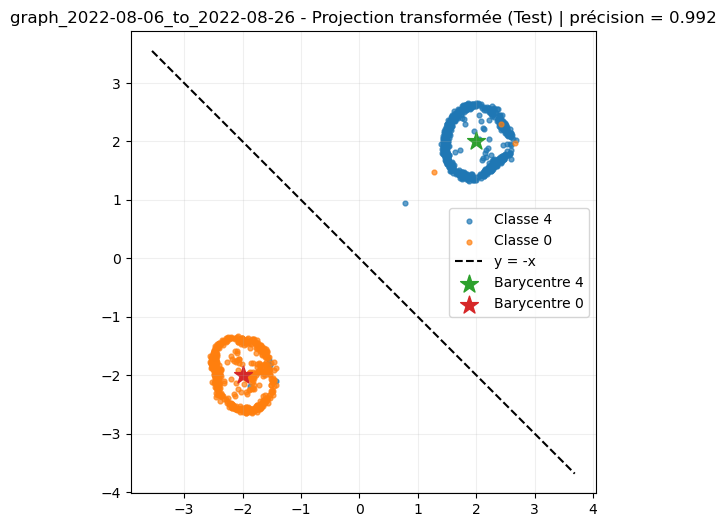


Traitement de graph_2022-08-13_to_2022-09-02
Train: 328 points
Test: 1315 points

 Accuracy sur TRAIN: 1.0000 (100.00%)
 Accuracy sur TEST: 0.9894 (98.94%)

 Matrice de confusion sur TEST:


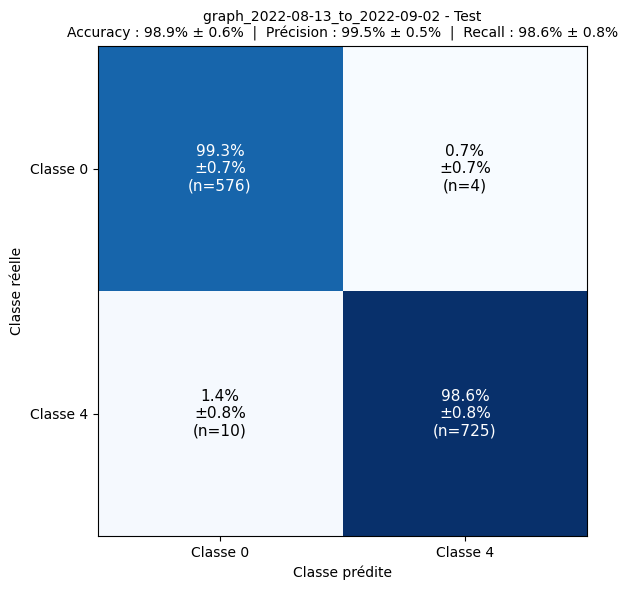

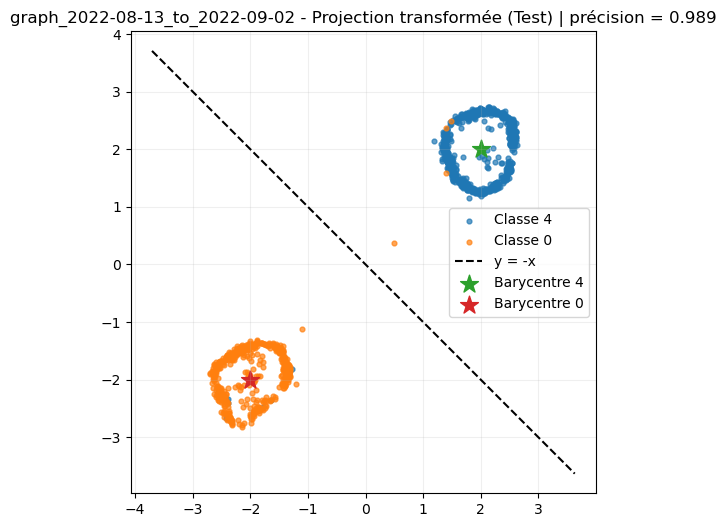


RÉSUMÉ DES ACCURACIES
graph_2022-01-01_to_2022-01-14: Train = 1.0000 | Test = 0.9585
graph_2022-01-01_to_2022-01-21: Train = 0.9950 | Test = 0.9698
graph_2022-01-08_to_2022-01-21: Train = 1.0000 | Test = 0.9710
graph_2022-01-08_to_2022-01-28: Train = 0.9949 | Test = 0.9686
graph_2022-01-15_to_2022-01-28: Train = 1.0000 | Test = 0.9484
graph_2022-01-15_to_2022-02-04: Train = 0.9905 | Test = 0.9715
graph_2022-01-22_to_2022-02-04: Train = 1.0000 | Test = 0.9632
graph_2022-01-22_to_2022-02-11: Train = 1.0000 | Test = 0.9692
graph_2022-01-29_to_2022-02-11: Train = 1.0000 | Test = 0.9691
graph_2022-01-29_to_2022-02-18: Train = 1.0000 | Test = 0.9774
graph_2022-02-05_to_2022-02-18: Train = 1.0000 | Test = 0.9560
graph_2022-02-05_to_2022-02-25: Train = 1.0000 | Test = 0.9765
graph_2022-02-12_to_2022-02-25: Train = 0.9948 | Test = 0.9608
graph_2022-02-12_to_2022-03-04: Train = 1.0000 | Test = 0.9753
graph_2022-02-19_to_2022-03-04: Train = 0.9856 | Test = 0.9579
graph_2022-02-19_to_2022-03-11: 

In [16]:
# Cellule qui calcul la presision de umap avec la methode des barrycentres
# Dictionnaire pour stocker les résultats des classifieurs par fichier
resultats_classifieurs = {}

for fichier, data in projections_supervisees.items():
    print(f"\n{'='*50}")
    print(f"Traitement de {fichier}")
    print(f"{'='*50}")
    
    # Récupération des données train et test
    X_train = data['train']      # coordonnées UMAP 2D du train
    y_train = data['y_train']    # labels du train (0 et 4)
    X_test = data['test']        # coordonnées UMAP 2D du test
    y_test = data['y_test']      # labels du test
    
    print(f"Train: {len(X_train)} points")
    print(f"Test: {len(X_test)} points")
    
    # Création et entraînement du classifieur
    clf = BarycenterClassifier(label_positive=4, label_negative=0, target=(2, 2))
    clf.fit(X_train, y_train)
    
    # Évaluation sur le train
    train_accuracy = clf.score(X_train, y_train)
    print(f"\n Accuracy sur TRAIN: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    
    # Évaluation sur le test
    test_accuracy = clf.score(X_test, y_test)
    print(f" Accuracy sur TEST: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    # Stockage du classifieur et des métriques
    resultats_classifieurs[fichier] = {
        'classifier': clf,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }
    
    # Affichage de la matrice de confusion pour le test
    print(f"\n Matrice de confusion sur TEST:")
    clf.plot_confusion_matrix(X_test, y_test, title=f"{fichier} - Test")
    
    # Affichage du plot des points transformés pour le test
    clf.plot(X_test, y_test, title=f"{fichier} - Projection transformée (Test)")

# Résumé final
print("\n" + "="*60)
print("RÉSUMÉ DES ACCURACIES")
print("="*60)

for fichier, res in resultats_classifieurs.items():
    print(f"{fichier}: Train = {res['train_accuracy']:.4f} | Test = {res['test_accuracy']:.4f}")

# Calcul de l'accuracy moyenne sur le test
avg_test_accuracy = np.mean([res['test_accuracy'] for res in resultats_classifieurs.values()])
print(f"\n Accuracy moyenne sur TEST (tous fichiers): {avg_test_accuracy:.4f} ({avg_test_accuracy*100:.2f}%)")

In [18]:
# Cellule qui calcul la presision de umap avec la methode de KNN
def confidence_interval(p, n, z=1.96):
    if n == 0:
        return 0.0
    return z * np.sqrt(p * (1 - p) / n)

resultats_knn = {}
for fichier, data in projections_supervisees.items():
    print("\n" + "="*50)
    print(f"KNN - {fichier}")
    print("="*50)

    X_train, y_train = data['train'], data['y_train']
    X_test,  y_test  = data['test'],  data['y_test']

    print(f"Train: {len(X_train)} points | Test: {len(X_test)} points")

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc    = accuracy_score(y_test, y_pred)
    ic_acc = confidence_interval(acc, len(y_test))

    resultats_knn[fichier] = {
        'accuracy':    acc,
        'ic_accuracy': ic_acc,
        'knn_model':   knn
    }

    print(f"\nAccuracy : {acc*100:.1f}% ± {ic_acc*100:.1f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Pro-climat (0)', 'Sceptique (4)']))

avg_acc = np.mean([res['accuracy'] for res in resultats_knn.values()])
print("\n" + "="*50)
print(f"ACCURACY MOYENNE SUR {len(resultats_knn)} FICHIERS: {avg_acc*100:.1f}%")


KNN - graph_2022-01-01_to_2022-01-14
Train: 168 points | Test: 675 points

Accuracy : 95.9% ± 1.5%

Classification Report:
                precision    recall  f1-score   support

Pro-climat (0)       0.90      0.89      0.89       133
 Sceptique (4)       0.97      0.98      0.97       542

      accuracy                           0.96       675
     macro avg       0.94      0.93      0.93       675
  weighted avg       0.96      0.96      0.96       675


KNN - graph_2022-01-01_to_2022-01-21
Train: 199 points | Test: 796 points

Accuracy : 97.0% ± 1.2%

Classification Report:
                precision    recall  f1-score   support

Pro-climat (0)       0.94      0.93      0.94       196
 Sceptique (4)       0.98      0.98      0.98       600

      accuracy                           0.97       796
     macro avg       0.96      0.96      0.96       796
  weighted avg       0.97      0.97      0.97       796


KNN - graph_2022-01-08_to_2022-01-21
Train: 172 points | Test: 689 points


# Celulle qui affichie les matrice de confusion pour le KNN
labels = ['Pro-climat (0)', 'Sceptique (4)']

fig, axes = plt.subplots(9, 5, figsize=(20, 36))
axes = axes.flatten()

for idx, fichier in enumerate(dictionnaire_embeddings.keys()):
    ax     = axes[idx]
    data   = projections_supervisees[fichier]
    knn    = resultats_knn[fichier]['knn_model']
    y_test = data['y_test']
    y_pred = knn.predict(data['test'])

    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]
    n_neg, n_pos = TN + FP, FN + TP
    n_total      = n_neg + n_pos

    cases = {
        (0, 0): (TN, n_neg),
        (0, 1): (FP, n_neg),
        (1, 0): (FN, n_pos),
        (1, 1): (TP, n_pos),
    }

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    accuracy  = (TP + TN) / n_total

    ic_precision = confidence_interval(precision, TP + FP)
    ic_recall    = confidence_interval(recall,    TP + FN)
    ic_accuracy  = confidence_interval(accuracy,  n_total)

    ax.imshow(cm, interpolation='nearest', cmap='Blues')

    for (i, j), (count, n_row) in cases.items():
        p  = count / n_row if n_row > 0 else 0.0
        ic = confidence_interval(p, n_row)
        text  = f"{p*100:.1f}%\n±{ic*100:.1f}%"
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, text, ha="center", va="center", color=color, fontsize=7)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Prédit", fontsize=6)
    ax.set_ylabel("Réel",   fontsize=6)
    ax.set_title(
        f"{fichier}\n"
        f"Acc {accuracy*100:.1f}%±{ic_accuracy*100:.1f}% | "
        f"P {precision*100:.1f}%±{ic_precision*100:.1f}% | "
        f"R {recall*100:.1f}%±{ic_recall*100:.1f}%",
        fontsize=6
    )

for idx in range(len(dictionnaire_embeddings), len(axes)):
    axes[idx].axis('off')

plt.suptitle("Matrices de Confusion KNN - UMAP Supervisé (10 parties)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()